In [1]:
# import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
import os
os.getcwd()

'/Users/aakanksha/Desktop/Aakanksha/ecommerce-customer-campaign-analytics/notebooks'

In [3]:
# load data

customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

products = pd.read_csv("../data/raw/olist_products_dataset.csv")

reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")

geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")

translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Products": products,
    "Reviews": reviews,
    "Sellers": sellers,
    "Geolocation": geolocation,
    "Translation": translation,
}

In [6]:
# create summary table

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,Customers,99441,5,0,0
1,Orders,99441,8,4908,0
2,Order Items,112650,7,0,0
3,Payments,103886,5,0,0
4,Products,32951,9,2448,0
5,Reviews,99224,7,145903,0
6,Sellers,3095,4,0,0
7,Geolocation,1000163,5,0,261831
8,Translation,71,2,0,0


In [7]:
summary_df.to_csv(
    "../reports/documentation/dataset_summary.csv",
    index=False
)

In [8]:
# display the first few rows of each dataset

for name, df in datasets.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nFirst Five Rows:")
    display(df.head())

    print("\n")

CUSTOMERS

Shape:
(99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data Types:
customer_id                   str
customer_unique_id            str
customer_zip_code_prefix    int64
customer_city                 str
customer_state                str
dtype: object

First Five Rows:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP




ORDERS

Shape:
(99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

First Five Rows:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00




ORDER ITEMS

Shape:
(112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Data Types:
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

First Five Rows:


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP




GEOLOCATION

Shape:
(1000163, 5)

Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Data Types:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                   str
geolocation_state                  str
dtype: object

First Five Rows:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP




TRANSLATION

Shape:
(71, 2)

Columns:
['product_category_name', 'product_category_name_english']

Data Types:
product_category_name            str
product_category_name_english    str
dtype: object

First Five Rows:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [9]:
for name, df in datasets.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    display(df.describe(include="all"))

CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,06b8999e2fba1a1fbc88172c00ba8bc7,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


ORDER ITEMS


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


GEOLOCATION


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


TRANSLATION


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


# Dataset Overview

This notebook performs Exploratory Data Analysis (EDA) on the Olist Brazilian E-commerce dataset.

The objective of this phase is to understand the structure, quality, and characteristics of the data before cleaning or building analytical models.

The dataset consists of nine related tables that capture different aspects of an e-commerce business, including customers, orders, products, payments, reviews, sellers, and geographic information.

During this phase, we will:

- Examine dataset dimensions
- Inspect data types
- Identify missing values
- Check for duplicate records
- Understand relationships between tables
- Explore customer, product, payment, and order behavior
- Generate business insights that will guide later SQL analysis and Tableau dashboards

# Initial Observations

After inspecting all nine datasets, several important observations can be made:

### Customers
- The Customers table contains customer location information and unique customer identifiers.
- A customer may appear multiple times because each order receives a new `customer_id`, while `customer_unique_id` identifies the actual customer.

### Orders
- Orders is the central transaction table.
- Each order contains purchase, approval, shipping, and delivery timestamps.
- Order status indicates the lifecycle of each purchase.

### Order Items
- One order may contain multiple products.
- Revenue analysis will primarily use this table because product prices are stored here.

### Payments
- Orders may have multiple payment records.
- Credit card payments appear to be the dominant payment method.
- Installment payments are available for customer payment behavior analysis.

### Products
- Product information includes category names and physical dimensions.
- Several descriptive attributes contain missing values and will require cleaning later.

### Reviews
- Review scores are mostly available.
- Many review titles and review comments are missing, which is expected because customers are not required to leave written feedback.

### Sellers
- Seller information includes geographic location.
- Seller performance can later be analyzed using revenue and review scores.

### Geolocation
- The geolocation table contains latitude and longitude information for Brazilian ZIP code prefixes.
- This table can be used for geographic visualizations if needed.

### Category Translation
- Product categories are stored in Portuguese.
- The translation table will be used to convert category names into English before reporting.

Overall, the dataset follows a relational database structure with Orders serving as the central table connecting customers, products, payments, reviews, and sellers.

In [10]:
key_columns = {
    "Customers": ["customer_id", "customer_unique_id"],
    "Orders": ["order_id", "customer_id"],
    "Order Items": ["order_id", "product_id", "seller_id"],
    "Payments": ["order_id"],
    "Products": ["product_id"],
    "Reviews": ["review_id", "order_id"],
    "Sellers": ["seller_id"],
}

for table, cols in key_columns.items():
    print("=" * 70)
    print(table)
    display(datasets[table][cols].head())

Customers


,customer_id,customer_unique_id
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066


Orders


,order_id,customer_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c


Order Items


...

,product_id
0,1e9e8ef04dbcff4541ed26657ea517e5
1,3aa071139cb16b67ca9e5dea641aaa2f
2,96bd76ec8810374ed1b65e291975717f
3,cef67bcfe19066a932b7673e239eb23d
4,9dc1a7de274444849c219cff195d0b71


Reviews


,review_id,order_id
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1


Sellers


,seller_id
0,3442f8959a84dea7ee197c632cb2df15
1,d1b65fc7debc3361ea86b5f14c68d2e2
2,ce3ad9de960102d0677a81f5d0bb7b2d
3,c0f3eea2e14555b6faeea3dd58c1b1c3
4,51a04a8a6bdcb23deccc82b0b80742cf


# Key Relationships Identified

The dataset follows a relational schema.

The primary relationships are:

- Customers → Orders (`customer_id`)
- Orders → Order Items (`order_id`)
- Orders → Payments (`order_id`)
- Orders → Reviews (`order_id`)
- Products → Order Items (`product_id`)
- Sellers → Order Items (`seller_id`)
- Product Categories → Translation Table (`product_category_name`)

These relationships will be used to build SQL joins, customer analytics, sales reporting, RFM analysis, cohort analysis, and Tableau dashboards in later phases.

# Data Quality Assessment

Before performing any analysis, it is important to evaluate the quality of the data.

This section examines:

- Missing values
- Duplicate records
- Unique values
- Data types
- Potential data quality issues

The findings from this assessment will guide the data cleaning process in the next phase.

In [11]:
# missing values

missing_summary = []

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        for col, count in missing.items():
            missing_summary.append({
                "Dataset": name,
                "Column": col,
                "Missing Values": count,
                "Missing %": round((count / len(df)) * 100, 2)
            })

missing_df = pd.DataFrame(missing_summary)

missing_df.sort_values(
    by=["Dataset", "Missing Values"],
    ascending=[True, False]
)

,Dataset,Column,Missing Values,Missing %
2,Orders,order_delivered_customer_date,2965,2.98
1,Orders,order_delivered_carrier_date,1783,1.79
0,Orders,order_approved_at,160,0.16
3,Products,product_category_name,610,1.85
4,Products,product_name_lenght,610,1.85
5,Products,product_description_lenght,610,1.85
6,Products,product_photos_qty,610,1.85
7,Products,product_weight_g,2,0.01
8,Products,product_length_cm,2,0.01
9,Products,product_height_cm,2,0.01


In [12]:
missing_df.to_csv(
    "../reports/documentation/missing_values_summary.csv",
    index=False
)

In [13]:
# duplicate analysis

duplicate_summary = []

for name, df in datasets.items():
    duplicate_summary.append({
        "Dataset": name,
        "Duplicate Rows": df.duplicated().sum(),
        "Total Rows": len(df),
        "Duplicate %": round(
            (df.duplicated().sum() / len(df)) * 100,
            2
        )
    })

duplicate_df = pd.DataFrame(duplicate_summary)

duplicate_df

,Dataset,Duplicate Rows,Total Rows,Duplicate %
0,Customers,0,99441,0.00
1,Orders,0,99441,0.00
2,Order Items,0,112650,0.00
3,Payments,0,103886,0.00
4,Products,0,32951,0.00
5,Reviews,0,99224,0.00
6,Sellers,0,3095,0.00
7,Geolocation,261831,1000163,26.18
8,Translation,0,71,0.00


In [14]:
duplicate_df.to_csv(
    "../reports/documentation/duplicate_summary.csv",
    index=False
)

In [15]:
# unique values analysis

unique_summary = []

for name, df in datasets.items():

    for col in df.columns:

        unique_summary.append({

            "Dataset": name,

            "Column": col,

            "Unique Values": df[col].nunique()

        })

unique_df = pd.DataFrame(unique_summary)

unique_df.head()

,Dataset,Column,Unique Values
0,Customers,customer_id,99441
1,Customers,customer_unique_id,96096
2,Customers,customer_zip_code_prefix,14994
3,Customers,customer_city,4119
4,Customers,customer_state,27


In [16]:
unique_df.to_csv(
    "../reports/documentation/unique_values_summary.csv",
    index=False
)

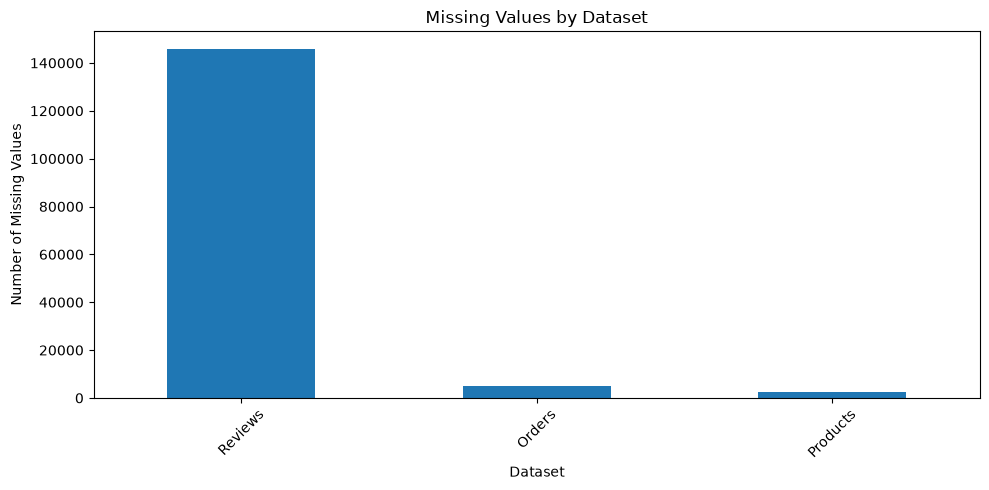

In [17]:
missing_counts = (
    missing_df.groupby("Dataset")["Missing Values"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

missing_counts.plot(kind="bar")

plt.title("Missing Values by Dataset")
plt.xlabel("Dataset")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/data_quality/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# data types summary

datatype_summary = []

for name, df in datasets.items():

    for col in df.columns:

        datatype_summary.append({

            "Dataset": name,

            "Column": col,

            "Data Type": str(df[col].dtype)

        })

datatype_df = pd.DataFrame(datatype_summary)

datatype_df.head()

,Dataset,Column,Data Type
0,Customers,customer_id,str
1,Customers,customer_unique_id,str
2,Customers,customer_zip_code_prefix,int64
3,Customers,customer_city,str
4,Customers,customer_state,str


In [19]:
datatype_df.to_csv(
    "../reports/documentation/data_types.csv",
    index=False
)

# Data Quality Findings

## Missing Values

Several datasets contain missing values.

The Products table has missing values in descriptive attributes such as product dimensions and category names.

The Reviews table has a large number of missing review comments, which is expected because written feedback is optional.

The Orders table contains missing delivery timestamps primarily for cancelled or undelivered orders.

---

## Duplicate Records

No major duplicate issues were identified during the initial assessment. Duplicate checks will be revisited after data cleaning.

---

## Data Types

Most identifier columns are stored as strings.

Several timestamp columns are currently stored as text and will be converted to datetime objects during the data cleaning phase.

---

## Overall Assessment

The dataset is generally well structured and suitable for analytical processing. Most data quality issues are expected for transactional e-commerce data and can be addressed during preprocessing.

## Orders Analysis

The Orders table represents the lifecycle of each customer order.

This section analyzes:

- Order status distribution
- Monthly order trends
- Annual order volume
- Purchase seasonality
- Approval time
- Delivery time
- Late-delivery performance

In [20]:
# convert order dates
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

orders[order_date_columns].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [21]:
# purchase date range
print(
    "Earliest purchase:",
    orders["order_purchase_timestamp"].min()
)

print(
    "Latest purchase:",
    orders["order_purchase_timestamp"].max()
)

Earliest purchase: 2016-09-04 21:15:19
Latest purchase: 2018-10-17 17:30:18


### Order status distribution


In [22]:
status_counts = orders["order_status"].value_counts()

status_summary = pd.DataFrame({
    "Orders": status_counts,
    "Percentage": (
        status_counts / len(orders) * 100
    ).round(2)
})

status_summary

,Orders,Percentage
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


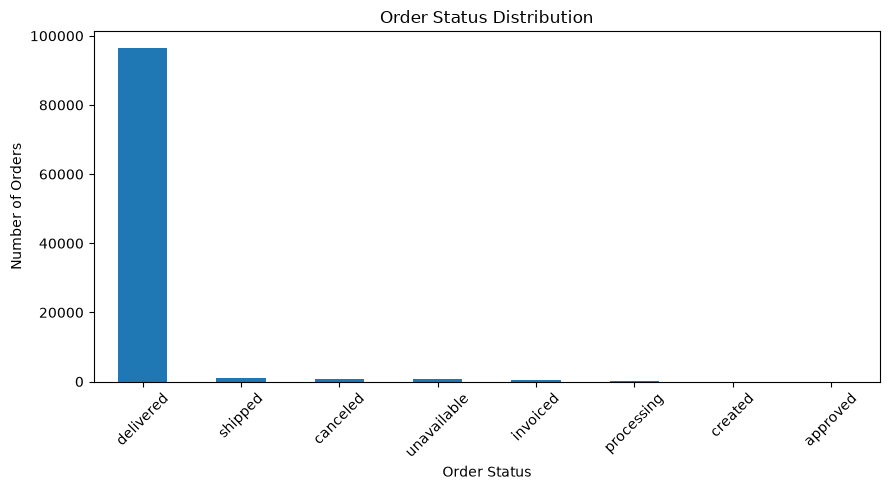

In [23]:
plt.figure(figsize=(9, 5))

status_counts.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/order_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Order Status Observations

- The dominant order status is:
- Percentage of delivered orders:
- Number of cancelled orders:
- Percentage of cancelled orders:
- Other operational statuses observed:

### Create time-related features

In [24]:
orders["purchase_year"] = (
    orders["order_purchase_timestamp"].dt.year
)

orders["purchase_month"] = (
    orders["order_purchase_timestamp"].dt.month
)

orders["purchase_month_name"] = (
    orders["order_purchase_timestamp"].dt.month_name()
)

orders["purchase_year_month"] = (
    orders["order_purchase_timestamp"].dt.to_period("M")
)

orders["purchase_day_of_week"] = (
    orders["order_purchase_timestamp"].dt.day_name()
)

orders["purchase_hour"] = (
    orders["order_purchase_timestamp"].dt.hour
)

### Monthly order trend

In [25]:
monthly_orders = (
    orders.groupby("purchase_year_month")
    .size()
    .reset_index(name="orders")
)

monthly_orders["purchase_year_month"] = (
    monthly_orders["purchase_year_month"].astype(str)
)

monthly_orders

,purchase_year_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


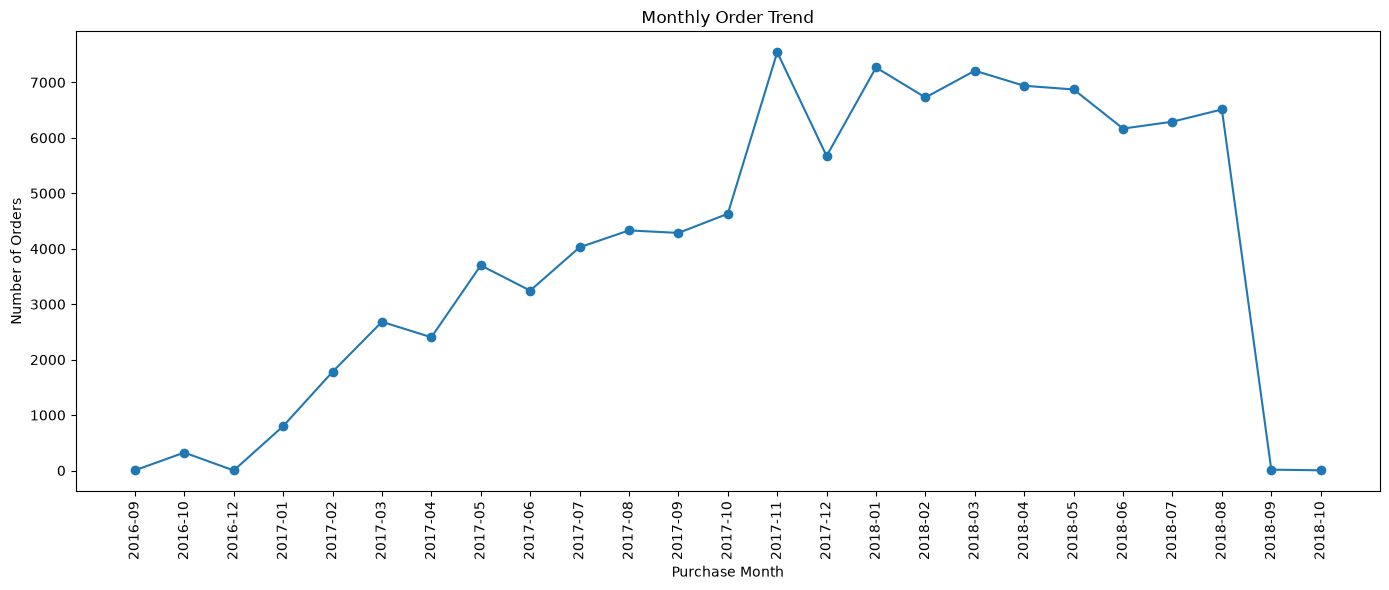

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_orders["purchase_year_month"],
    monthly_orders["orders"],
    marker="o"
)

plt.title("Monthly Order Trend")
plt.xlabel("Purchase Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/monthly_order_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Monthly Trend Observations

- Month with the highest order volume:
- Month with the lowest order volume:
- General growth or decline pattern:
- Any sudden spikes or drops:
- Possible effect of partial first or final months:

### Orders by year

In [27]:
yearly_orders = (
    orders.groupby("purchase_year")
    .size()
    .reset_index(name="orders")
)

yearly_orders

,purchase_year,orders
0,2016,329
1,2017,45101
2,2018,54011


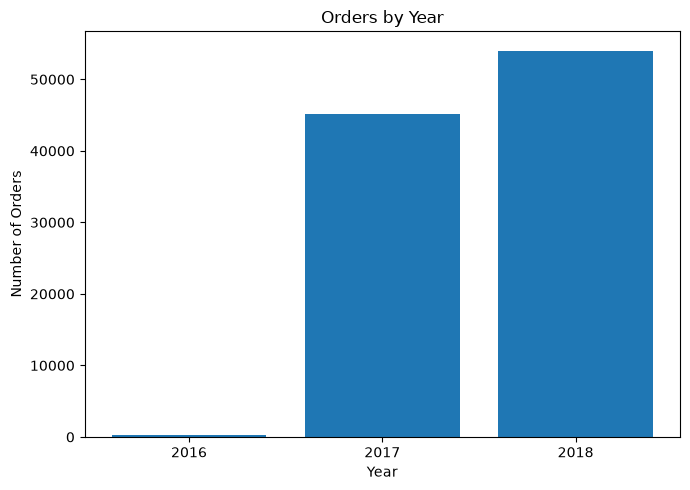

In [28]:
plt.figure(figsize=(7, 5))

plt.bar(
    yearly_orders["purchase_year"].astype(str),
    yearly_orders["orders"]
)

plt.title("Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/orders_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Purchase seasonality by month

In [29]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

orders_by_month = (
    orders["purchase_month_name"]
    .value_counts()
    .reindex(month_order)
)

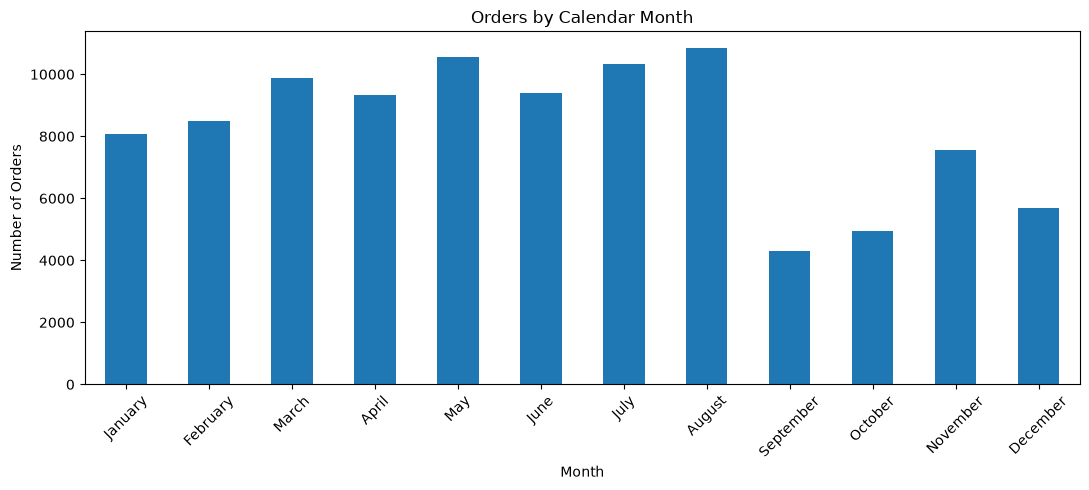

In [30]:
plt.figure(figsize=(11, 5))

orders_by_month.plot(kind="bar")

plt.title("Orders by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/orders_by_calendar_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Orders by day of week

In [31]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

orders_by_day = (
    orders["purchase_day_of_week"]
    .value_counts()
    .reindex(day_order)
)

orders_by_day

purchase_day_of_week
Monday       16196
Tuesday      15963
Wednesday    15552
Thursday     14761
Friday       14122
Saturday     10887
Sunday       11960
Name: count, dtype: int64

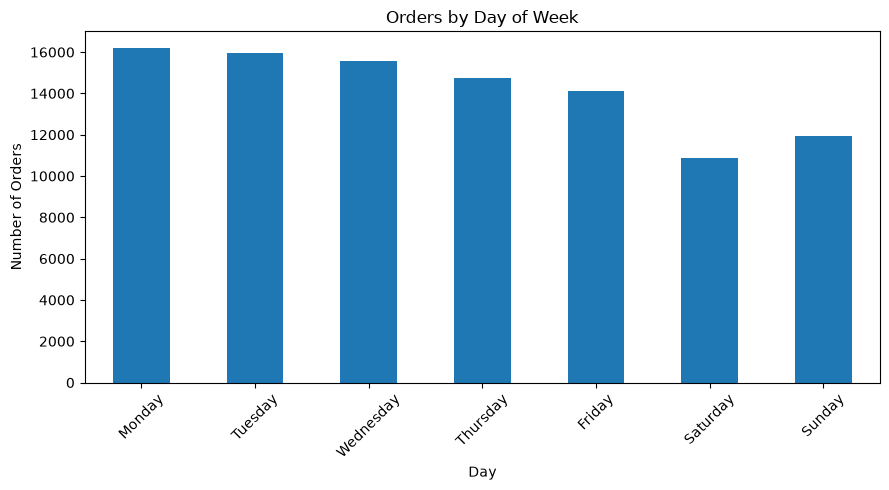

In [32]:
plt.figure(figsize=(9, 5))

orders_by_day.plot(kind="bar")

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/orders_by_day_of_week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Orders by hour

In [33]:
orders_by_hour = (
    orders.groupby("purchase_hour")
    .size()
    .reset_index(name="orders")
)

orders_by_hour

,purchase_hour,orders
0,0,2394
1,1,1170
2,2,510
3,3,272
4,4,206
5,5,188
6,6,502
7,7,1231
8,8,2967
9,9,4785


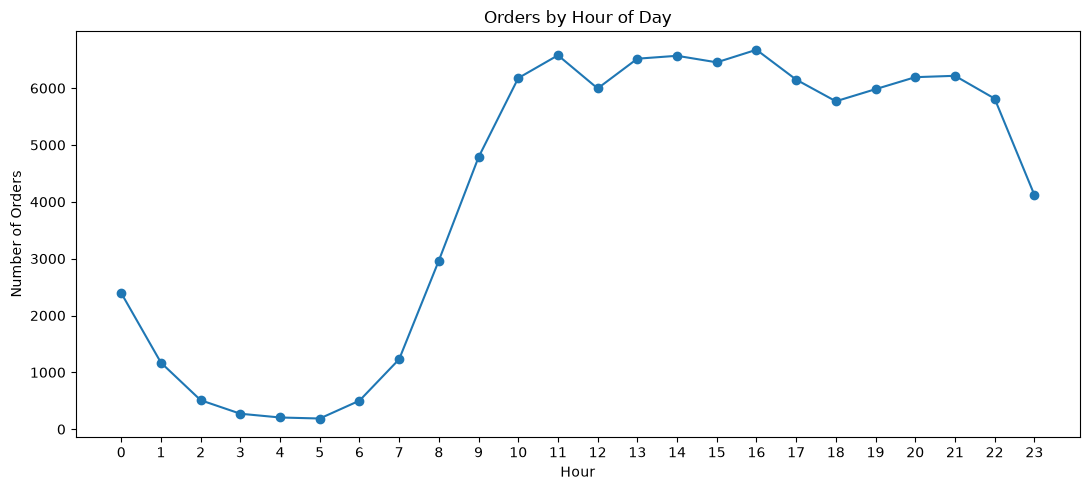

In [34]:
plt.figure(figsize=(11, 5))

plt.plot(
    orders_by_hour["purchase_hour"],
    orders_by_hour["orders"],
    marker="o"
)

plt.title("Orders by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")
plt.xticks(range(0, 24))

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/orders_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Order approval time

In [35]:
orders["approval_hours"] = (
    orders["order_approved_at"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 3600

orders["approval_hours"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    99281.000000
mean        10.419094
std         26.038004
min          0.000000
50%          0.343333
75%         14.580833
90%         34.659722
95%         48.463611
99%         90.166500
max       4509.180556
Name: approval_hours, dtype: float64

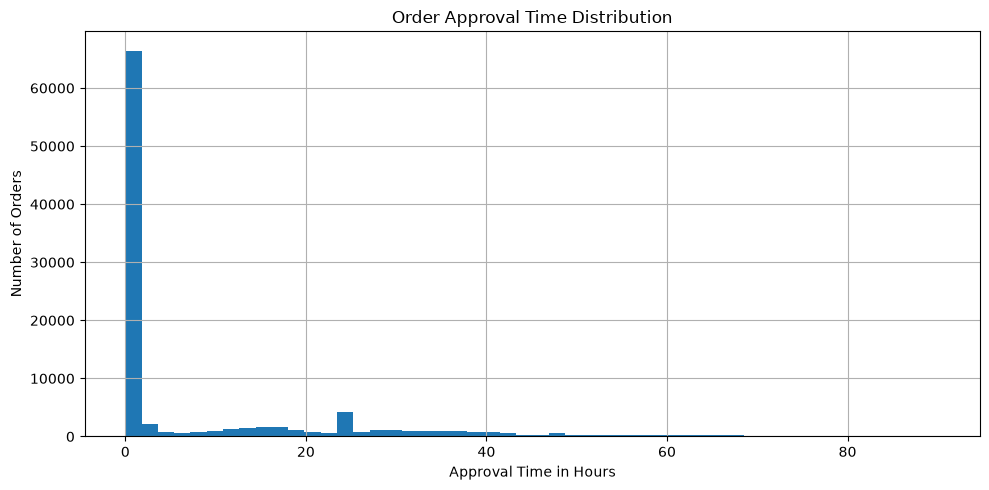

In [36]:
approval_limit = orders["approval_hours"].quantile(0.99)

plt.figure(figsize=(10, 5))

orders.loc[
    orders["approval_hours"].between(0, approval_limit),
    "approval_hours"
].hist(bins=50)

plt.title("Order Approval Time Distribution")
plt.xlabel("Approval Time in Hours")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/approval_time_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Delivery time

In [37]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders["delivery_days"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
50%         10.217755
75%         15.720327
90%         23.097604
95%         29.276016
99%         46.049913
max        209.628611
Name: delivery_days, dtype: float64

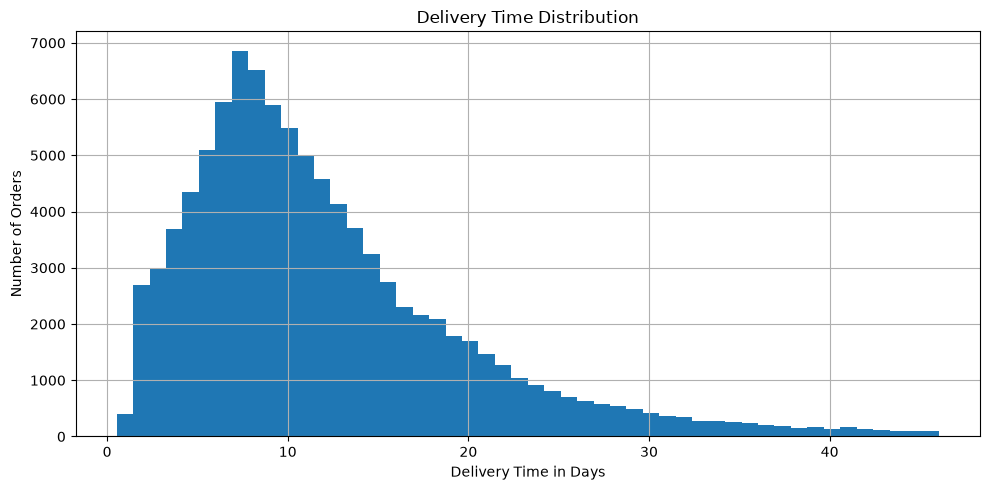

In [38]:
delivery_limit = orders["delivery_days"].quantile(0.99)

plt.figure(figsize=(10, 5))

orders.loc[
    orders["delivery_days"].between(0, delivery_limit),
    "delivery_days"
].hist(bins=50)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time in Days")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../reports/figures/logistics/delivery_time_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Late deliveries

In [39]:
delivered_orders = orders[
    (orders["order_status"] == "delivered")
    & orders["order_delivered_customer_date"].notna()
    & orders["order_estimated_delivery_date"].notna()
].copy()

delivered_orders["late_delivery"] = (
    delivered_orders["order_delivered_customer_date"]
    > delivered_orders["order_estimated_delivery_date"]
)

late_delivery_summary = (
    delivered_orders["late_delivery"]
    .value_counts()
    .rename(index={
        False: "On Time or Early",
        True: "Late"
    })
)

late_delivery_summary

late_delivery
On Time or Early    88644
Late                 7826
Name: count, dtype: int64

In [40]:
late_delivery_percentage = (
    delivered_orders["late_delivery"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

late_delivery_percentage

late_delivery
False    91.89
True      8.11
Name: proportion, dtype: float64

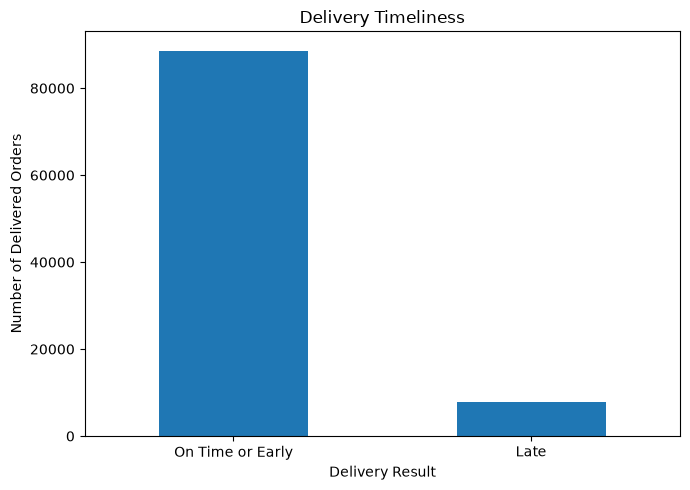

In [41]:
plt.figure(figsize=(7, 5))

late_delivery_summary.plot(kind="bar")

plt.title("Delivery Timeliness")
plt.xlabel("Delivery Result")
plt.ylabel("Number of Delivered Orders")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/logistics/delivery_timeliness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Days early or late

In [42]:
delivered_orders["delivery_difference_days"] = (
    delivered_orders["order_delivered_customer_date"]
    - delivered_orders["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

delivered_orders["delivery_difference_days"].describe()

count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_difference_days, dtype: float64

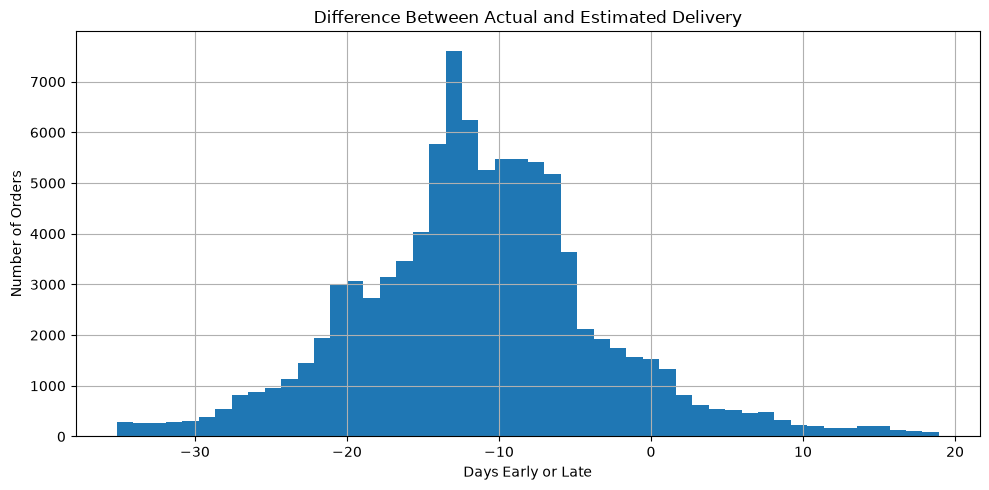

In [43]:
difference_lower = (
    delivered_orders["delivery_difference_days"]
    .quantile(0.01)
)

difference_upper = (
    delivered_orders["delivery_difference_days"]
    .quantile(0.99)
)

plt.figure(figsize=(10, 5))

delivered_orders.loc[
    delivered_orders["delivery_difference_days"].between(
        difference_lower,
        difference_upper
    ),
    "delivery_difference_days"
].hist(bins=50)

plt.title("Difference Between Actual and Estimated Delivery")
plt.xlabel("Days Early or Late")
plt.ylabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../reports/figures/logistics/delivery_difference_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Customer Analysis

This section explores:

- Total customer records
- Unique customers
- Repeat-customer indication
- Customer distribution by state
- Customer distribution by city
- Geographic concentration of the customer base

`customer_unique_id` is used for customer-level analysis because the same customer may receive a different `customer_id` for separate orders.

### Customer counts

In [44]:
customer_records = customers["customer_id"].nunique()

unique_customers = (
    customers["customer_unique_id"].nunique()
)

print("Customer records:", customer_records)
print("Unique customers:", unique_customers)
print(
    "Difference:",
    customer_records - unique_customers
)

Customer records: 99441
Unique customers: 96096
Difference: 3345


### Number of order records per unique customer

In [45]:
customer_record_frequency = (
    customers.groupby("customer_unique_id")
    ["customer_id"]
    .nunique()
    .value_counts()
    .sort_index()
)

customer_record_frequency

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

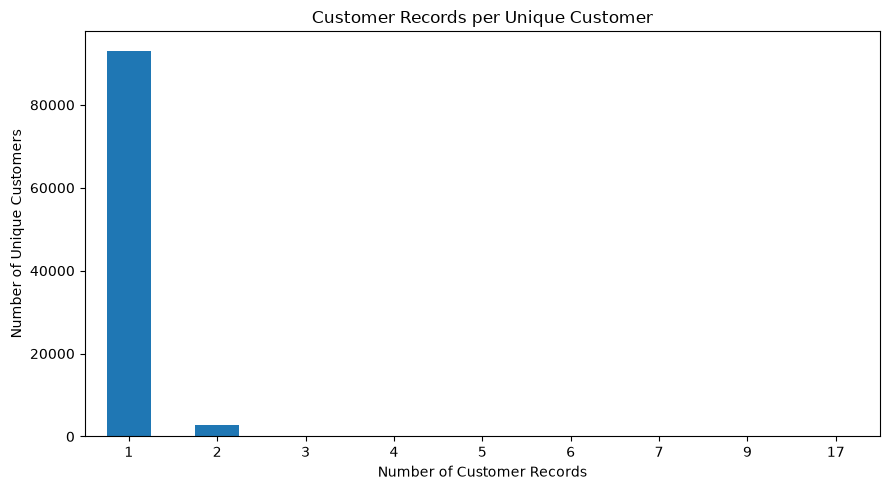

In [46]:
plt.figure(figsize=(9, 5))

customer_record_frequency.head(10).plot(kind="bar")

plt.title("Customer Records per Unique Customer")
plt.xlabel("Number of Customer Records")
plt.ylabel("Number of Unique Customers")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/customers/customer_record_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Customers by state

In [47]:
customers_by_state = (
    customers["customer_state"]
    .value_counts()
)

customers_by_state.head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

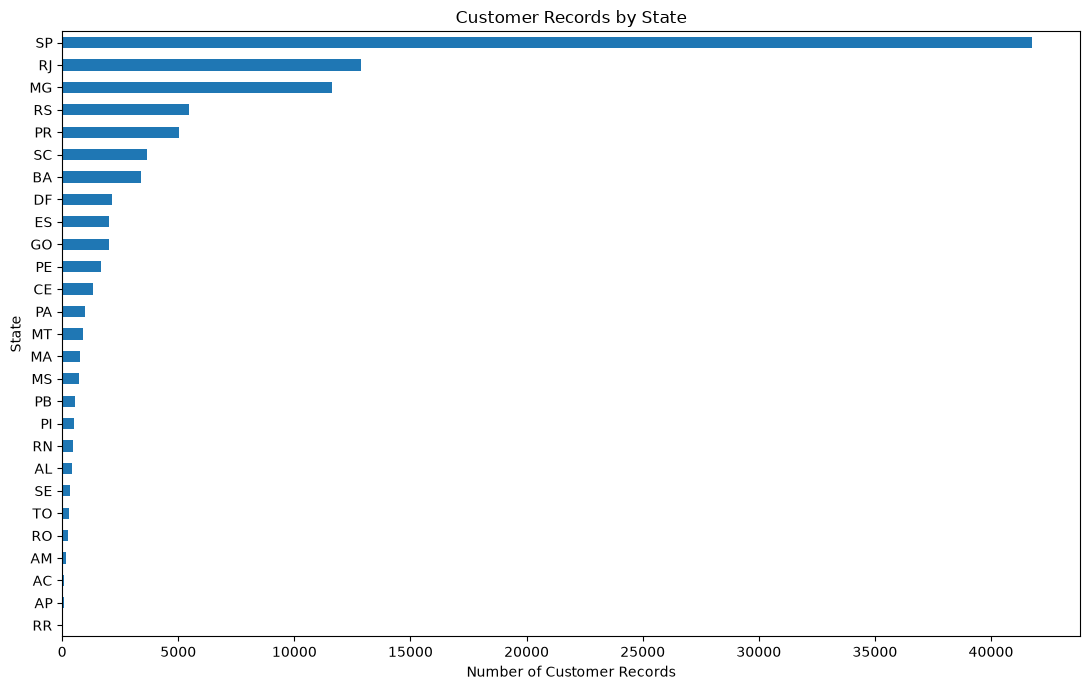

In [48]:
plt.figure(figsize=(11, 7))

customers_by_state.plot(kind="barh")

plt.title("Customer Records by State")
plt.xlabel("Number of Customer Records")
plt.ylabel("State")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../reports/figures/customers/customers_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Top customer cities

In [49]:
top_customer_cities = (
    customers["customer_city"]
    .value_counts()
    .head(15)
)

top_customer_cities

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
Name: count, dtype: int64

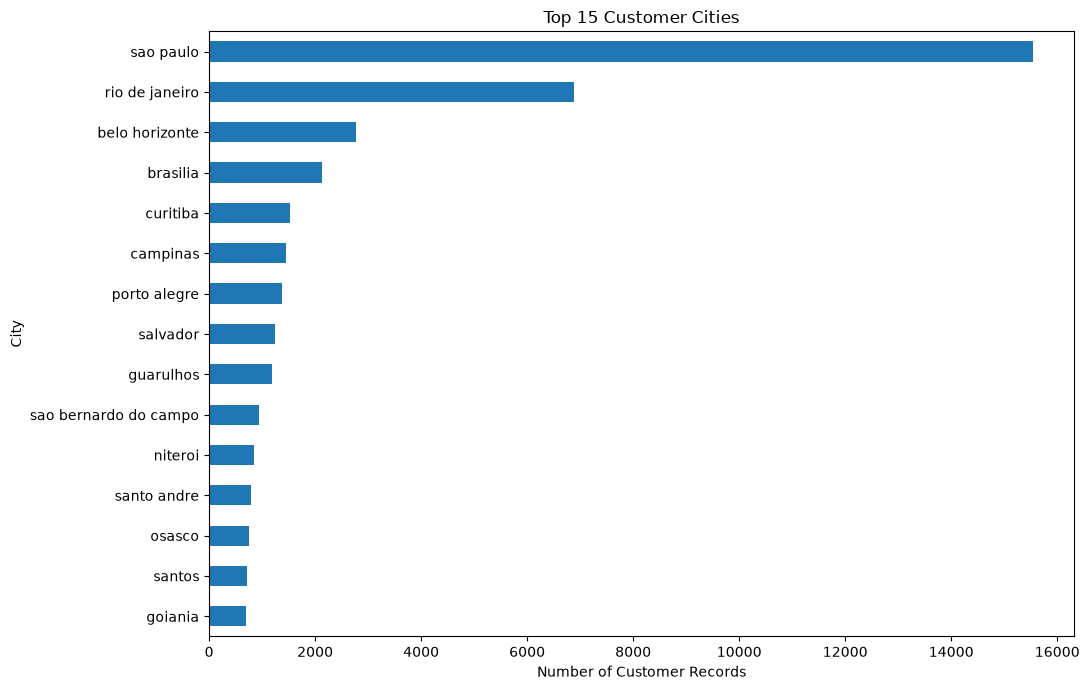

In [50]:
plt.figure(figsize=(11, 7))

top_customer_cities.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Customer Cities")
plt.xlabel("Number of Customer Records")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    "../reports/figures/customers/top_customer_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### State concentration

In [51]:
customer_state_share = (
    customers_by_state
    / customers_by_state.sum()
    * 100
).round(2)

customer_state_share.head(10)

customer_state
SP    41.98
RJ    12.92
MG    11.70
RS     5.50
PR     5.07
SC     3.66
BA     3.40
DF     2.15
ES     2.04
GO     2.03
Name: count, dtype: float64

In [52]:
top_5_state_share = customer_state_share.head(5).sum()

print(
    "Customer share represented by top five states:",
    round(top_5_state_share, 2),
    "%"
)

Customer share represented by top five states: 77.17 %


# Product Analysis

This section examines:

- Number of products
- Number of categories
- Missing product attributes
- Product category distribution
- Product price and freight distributions
- Product dimensions and weight

### Translate product categories

In [53]:
products_analysis = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products_analysis.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [54]:
# create failback for missing translations
products_analysis[
    "product_category_name_english"
] = products_analysis[
    "product_category_name_english"
].fillna("Unknown")

### Product counts

In [55]:
print(
    "Unique products:",
    products_analysis["product_id"].nunique()
)

print(
    "Portuguese categories:",
    products_analysis[
        "product_category_name"
    ].nunique()
)

print(
    "Translated categories:",
    products_analysis[
        "product_category_name_english"
    ].nunique()
)

Unique products: 32951
Portuguese categories: 73
Translated categories: 72


### Top categories by product count

In [56]:
top_product_categories = (
    products_analysis[
        "product_category_name_english"
    ]
    .value_counts()
    .head(15)
)

top_product_categories

product_category_name_english
bed_bath_table              3029
sports_leisure              2867
furniture_decor             2657
health_beauty               2444
housewares                  2335
auto                        1900
computers_accessories       1639
toys                        1411
watches_gifts               1329
telephony                   1134
baby                         919
perfumery                    868
stationery                   849
fashion_bags_accessories     849
cool_stuff                   789
Name: count, dtype: int64

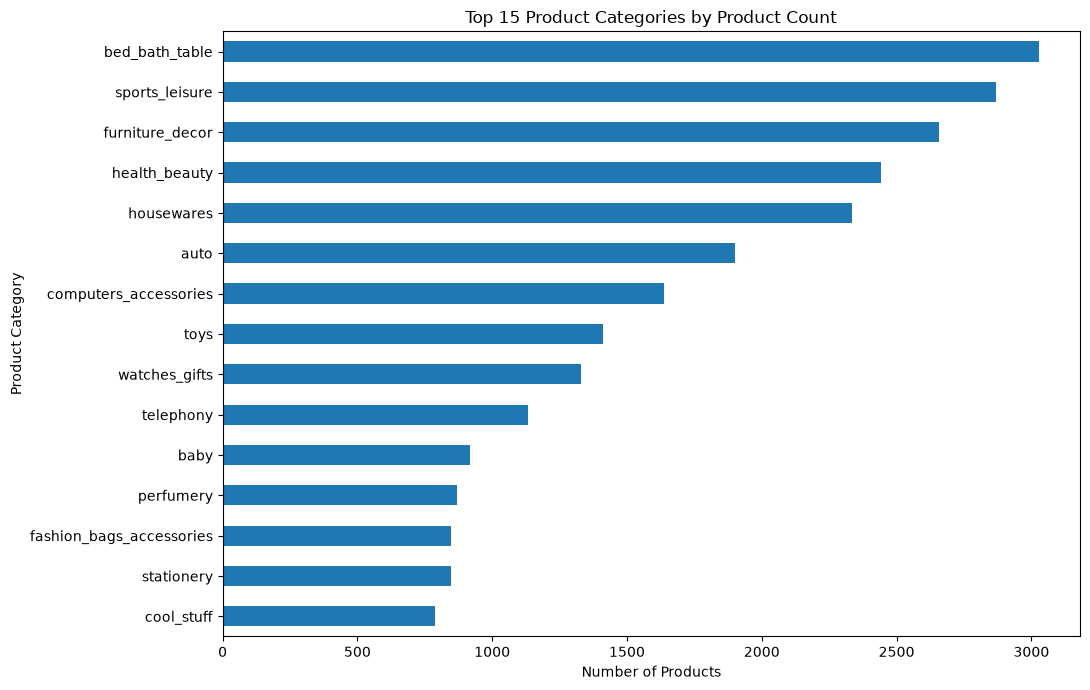

In [57]:
plt.figure(figsize=(11, 7))

top_product_categories.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Product Categories by Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig(
    "../reports/figures/products/top_categories_by_product_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Product attribute distributions

In [58]:
product_numeric_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
]

products_analysis[
    product_numeric_columns
].describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


### Product weight histogram

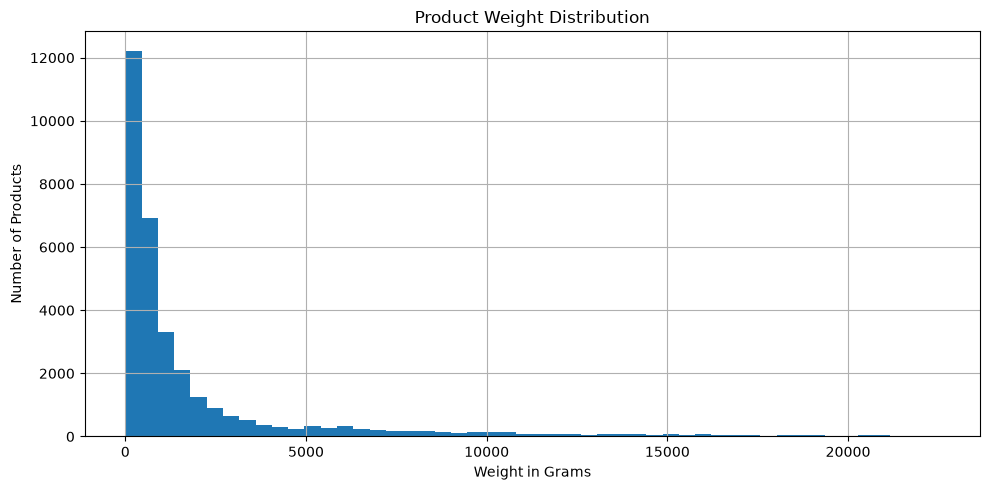

In [59]:
weight_limit = (
    products_analysis["product_weight_g"]
    .quantile(0.99)
)

plt.figure(figsize=(10, 5))

products_analysis.loc[
    products_analysis["product_weight_g"].between(
        0,
        weight_limit
    ),
    "product_weight_g"
].hist(bins=50)

plt.title("Product Weight Distribution")
plt.xlabel("Weight in Grams")
plt.ylabel("Number of Products")

plt.tight_layout()

plt.savefig(
    "../reports/figures/products/product_weight_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price distribution

In [60]:
order_items["price"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
50%          74.990000
75%         134.900000
90%         229.800000
95%         349.900000
99%         890.000000
max        6735.000000
Name: price, dtype: float64

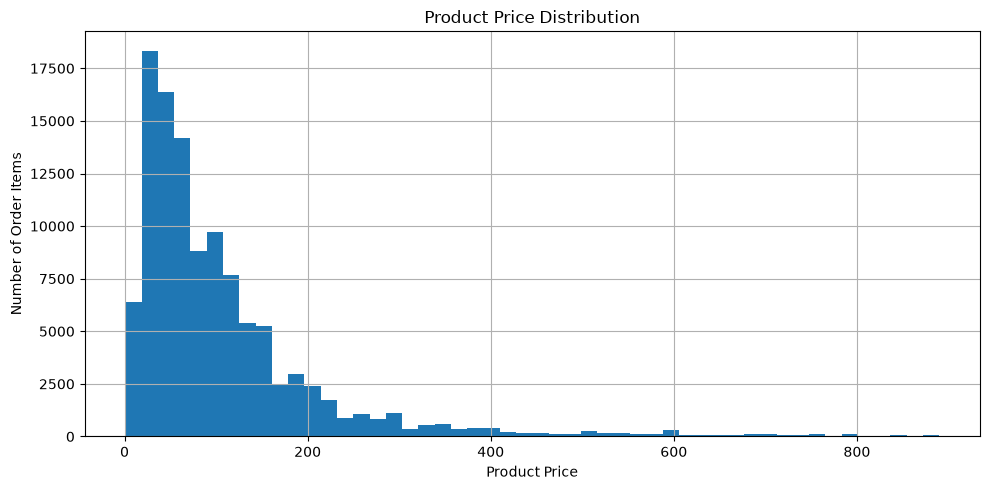

In [61]:
price_limit = order_items["price"].quantile(0.99)

plt.figure(figsize=(10, 5))

order_items.loc[
    order_items["price"].between(0, price_limit),
    "price"
].hist(bins=50)

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Number of Order Items")

plt.tight_layout()

plt.savefig(
    "../reports/figures/products/product_price_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Fright distribution

In [62]:
order_items["freight_value"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
50%          16.260000
75%          21.150000
90%          34.041000
95%          45.120000
99%          84.520000
max         409.680000
Name: freight_value, dtype: float64

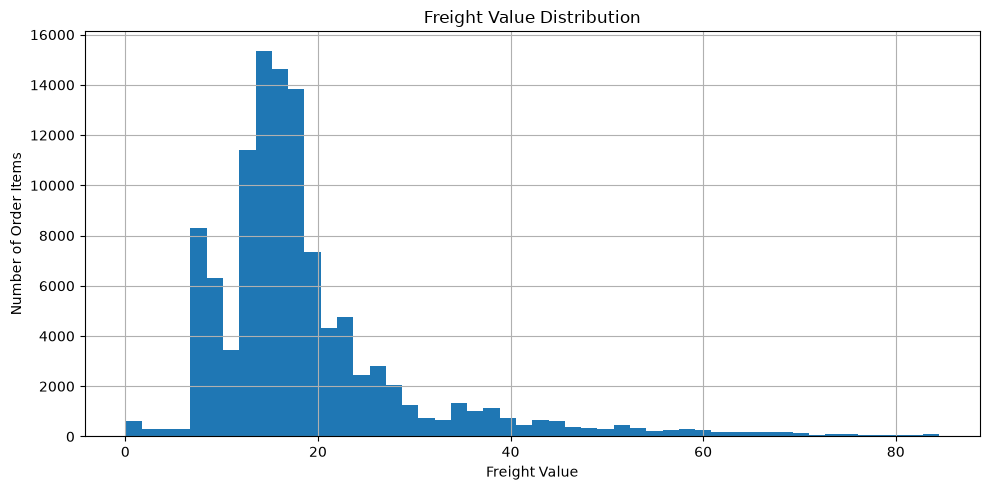

In [63]:
freight_limit = (
    order_items["freight_value"].quantile(0.99)
)

plt.figure(figsize=(10, 5))

order_items.loc[
    order_items["freight_value"].between(
        0,
        freight_limit
    ),
    "freight_value"
].hist(bins=50)

plt.title("Freight Value Distribution")
plt.xlabel("Freight Value")
plt.ylabel("Number of Order Items")

plt.tight_layout()

plt.savefig(
    "../reports/figures/products/freight_value_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price boxplot

/var/folders/js/y8j_fs4940307y29pznl4hvw0000gn/T/ipykernel_28319/335302935.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


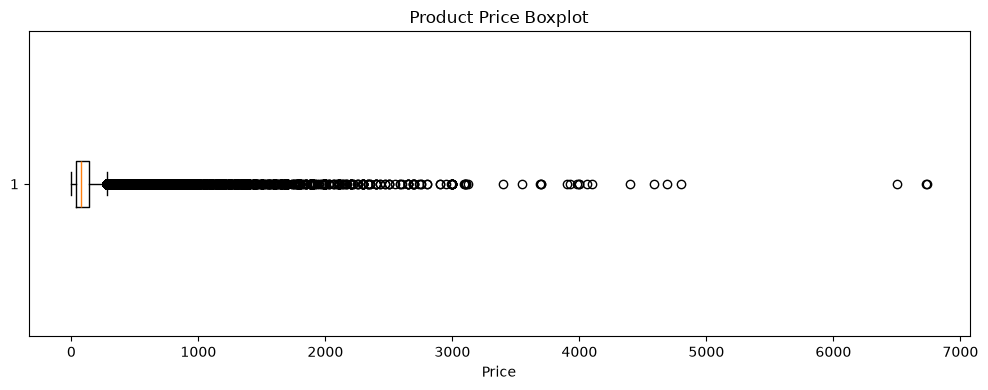

In [64]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    order_items["price"].dropna(),
    vert=False
)

plt.title("Product Price Boxplot")
plt.xlabel("Price")

plt.tight_layout()

plt.savefig(
    "../reports/figures/products/product_price_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Payment Analysis

This section examines:

- Payment methods
- Payment value distribution
- Installment behavior
- Orders with multiple payment records

### Payment methods

In [65]:
payment_type_counts = (
    payments["payment_type"].value_counts()
)

payment_type_summary = pd.DataFrame({
    "payments": payment_type_counts,
    "percentage": (
        payment_type_counts
        / len(payments)
        * 100
    ).round(2)
})

payment_type_summary

,payments,percentage
payment_type,,
credit_card,76795,73.92
boleto,19784,19.04
voucher,5775,5.56
debit_card,1529,1.47
not_defined,3,0.00


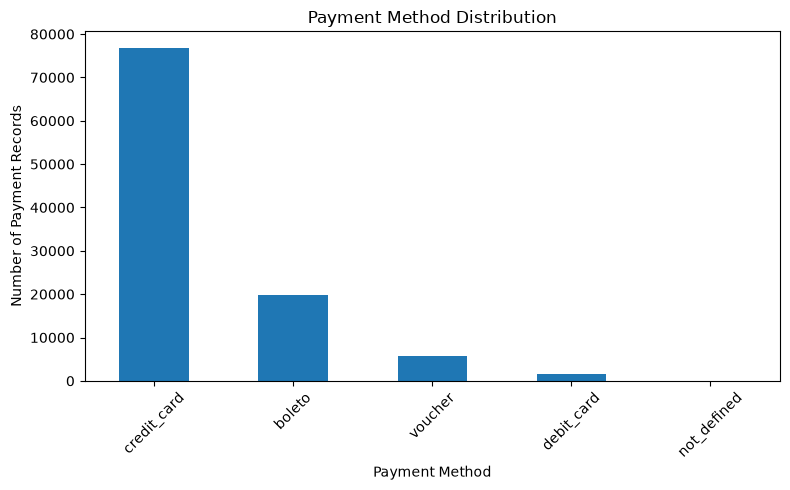

In [66]:
plt.figure(figsize=(8, 5))

payment_type_counts.plot(kind="bar")

plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Payment Records")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/figures/payments/payment_method_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Installment distribution

In [67]:
installment_counts = (
    payments["payment_installments"]
    .value_counts()
    .sort_index()
)

installment_counts.head(20)

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
Name: count, dtype: int64

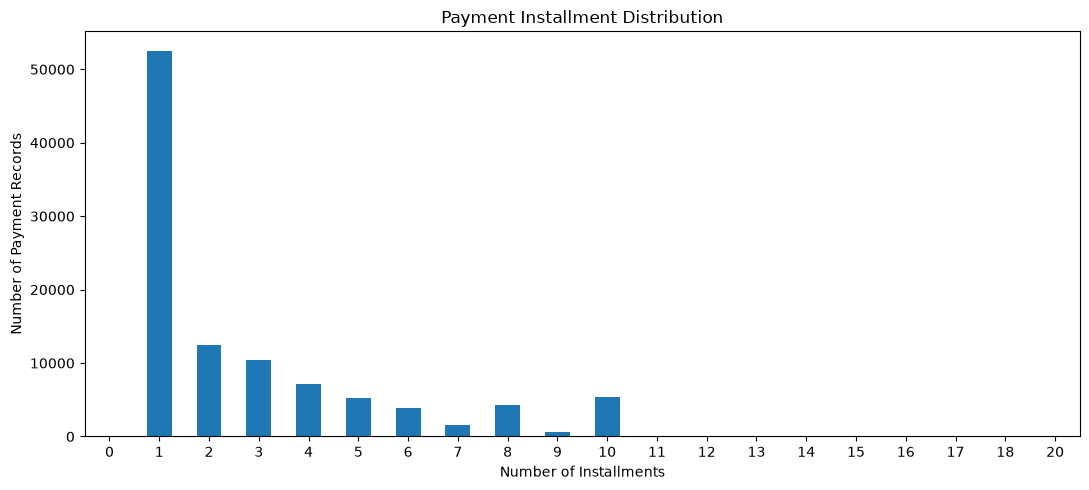

In [68]:
plt.figure(figsize=(11, 5))

installment_counts.head(20).plot(kind="bar")

plt.title("Payment Installment Distribution")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Payment Records")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/payments/installment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Payment value distribution

In [69]:
payments["payment_value"].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
50%         100.000000
75%         171.837500
90%         297.270000
95%         437.635000
99%        1039.916500
max       13664.080000
Name: payment_value, dtype: float64

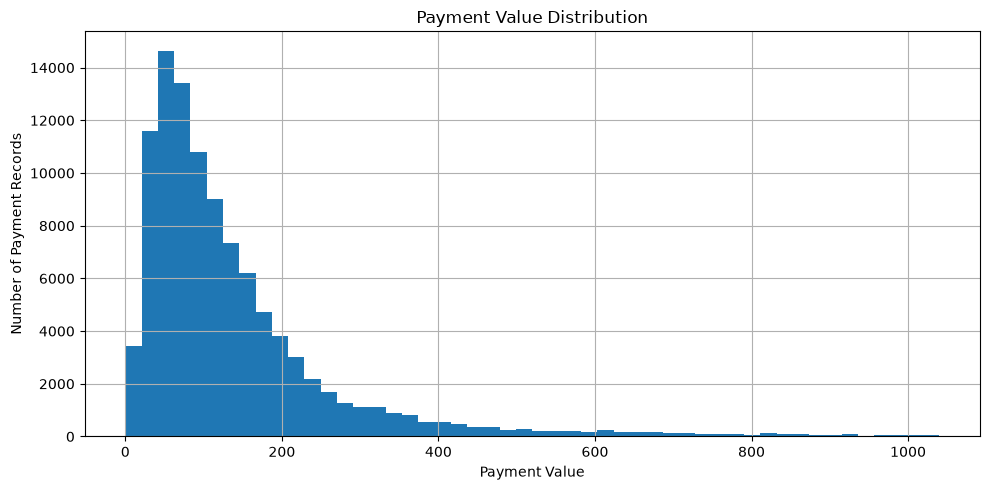

In [70]:
payment_value_limit = (
    payments["payment_value"].quantile(0.99)
)

plt.figure(figsize=(10, 5))

payments.loc[
    payments["payment_value"].between(
        0,
        payment_value_limit
    ),
    "payment_value"
].hist(bins=50)

plt.title("Payment Value Distribution")
plt.xlabel("Payment Value")
plt.ylabel("Number of Payment Records")

plt.tight_layout()

plt.savefig(
    "../reports/figures/payments/payment_value_histogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Multiple payment records per order

In [71]:
payments_per_order = (
    payments.groupby("order_id")
    .size()
)

payments_per_order.describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

In [72]:
payments_per_order_counts = (
    payments_per_order
    .value_counts()
    .sort_index()
)

payments_per_order_counts.head(10)

1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
10        5
Name: count, dtype: int64

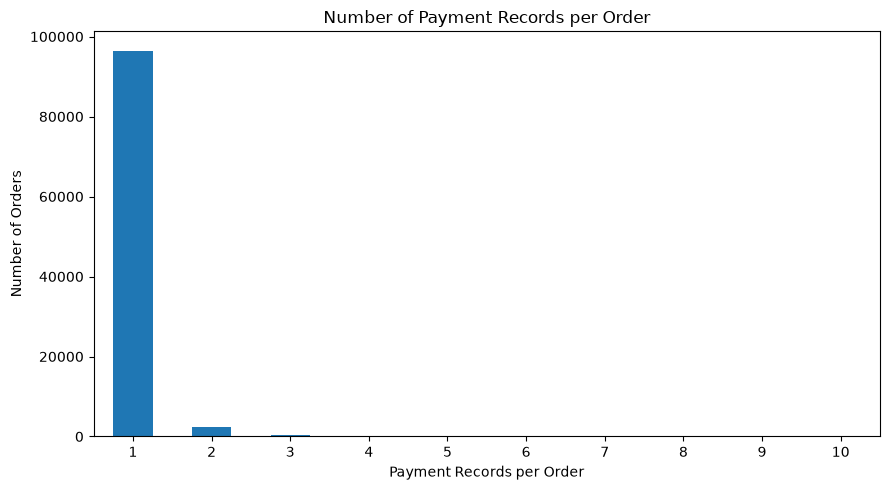

In [73]:
plt.figure(figsize=(9, 5))

payments_per_order_counts.head(10).plot(
    kind="bar"
)

plt.title("Number of Payment Records per Order")
plt.xlabel("Payment Records per Order")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/payments/payments_per_order.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Review Analysis

This section examines:

- Review-score distribution
- Average customer rating
- Availability of written review comments
- Relationship between delivery performance and satisfaction

### Review score summary

In [74]:
review_score_counts = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_score_summary = pd.DataFrame({
    "reviews": review_score_counts,
    "percentage": (
        review_score_counts
        / len(reviews)
        * 100
    ).round(2)
})

review_score_summary

,reviews,percentage
review_score,,
1,11424,11.51
2,3151,3.18
3,8179,8.24
4,19142,19.29
5,57328,57.78


In [75]:
print(
    "Average review score:",
    round(reviews["review_score"].mean(), 2)
)

print(
    "Median review score:",
    reviews["review_score"].median()
)

Average review score: 4.09
Median review score: 5.0


### Review-score chart

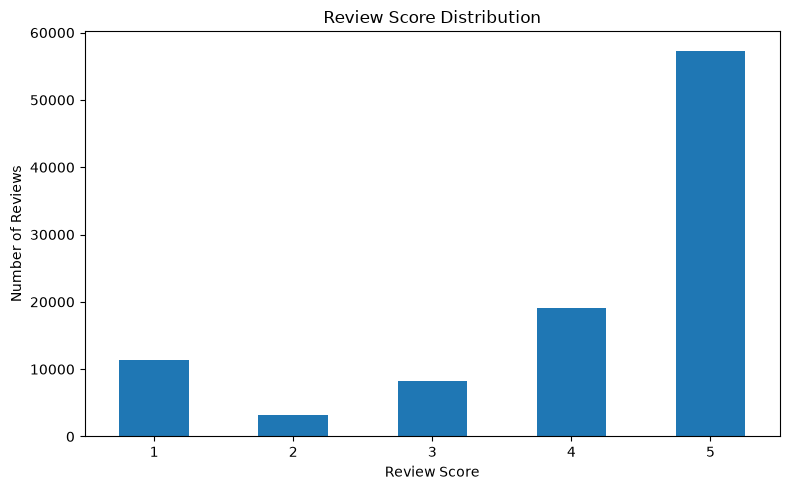

In [76]:
plt.figure(figsize=(8, 5))

review_score_counts.plot(kind="bar")

plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/reviews/review_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Written-review availability

In [77]:
review_text_availability = pd.Series({
    "Title Available": (
        reviews["review_comment_title"]
        .notna()
        .sum()
    ),
    "Message Available": (
        reviews["review_comment_message"]
        .notna()
        .sum()
    ),
})

review_text_availability

Title Available      11568
Message Available    40977
dtype: int64

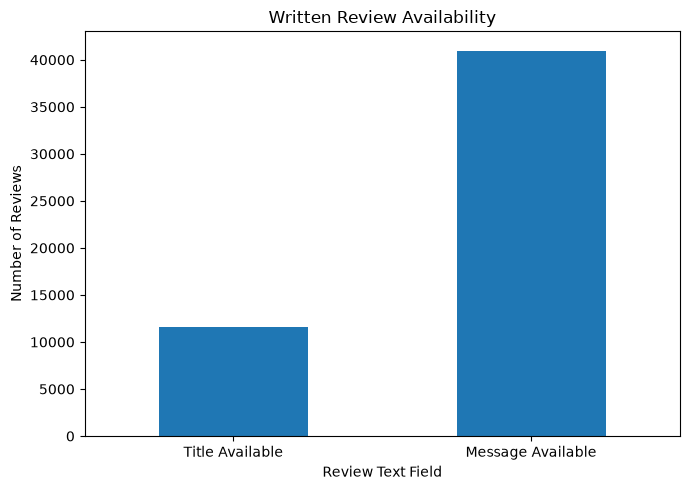

In [78]:
plt.figure(figsize=(7, 5))

review_text_availability.plot(kind="bar")

plt.title("Written Review Availability")
plt.xlabel("Review Text Field")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/reviews/written_review_availability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 14. Seller Analysis

This section explores:

- Number of sellers
- Seller distribution by state
- Seller distribution by city
- Geographic concentration of marketplace supply

### 14.1 Seller counts

In [79]:
print(
    "Unique sellers:",
    sellers["seller_id"].nunique()
)

print(
    "Seller states:",
    sellers["seller_state"].nunique()
)

print(
    "Seller cities:",
    sellers["seller_city"].nunique()
)

Unique sellers: 3095
Seller states: 23
Seller cities: 611


### 14.2 Sellers by state

In [80]:
sellers_by_state = (
    sellers["seller_state"].value_counts()
)

sellers_by_state

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

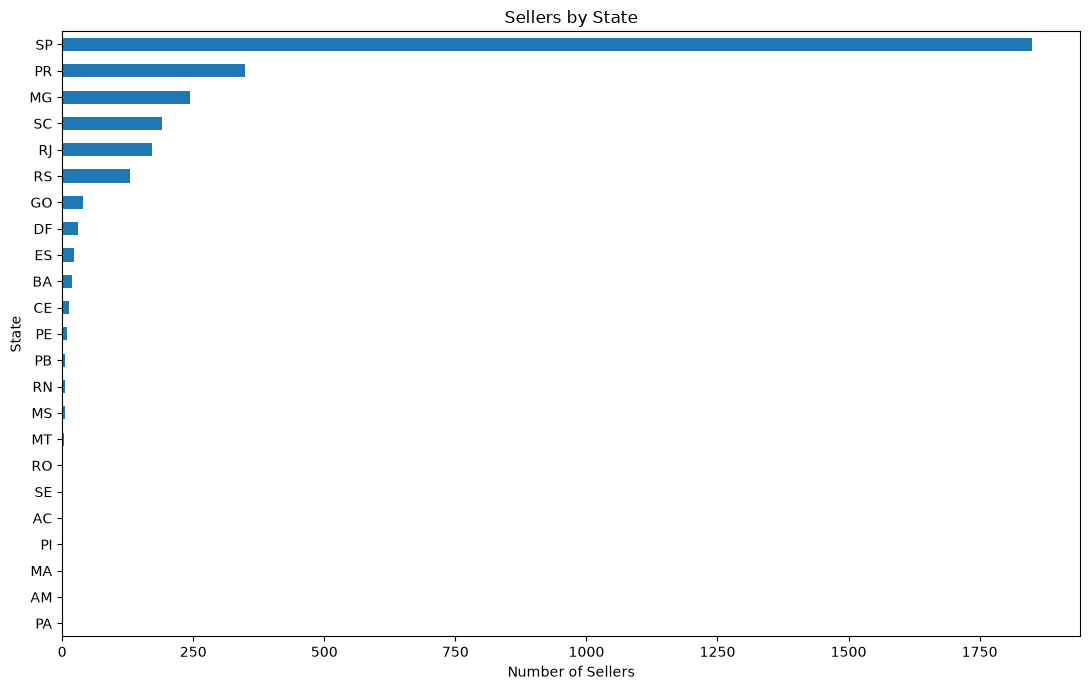

In [81]:
plt.figure(figsize=(11, 7))

sellers_by_state.plot(kind="barh")

plt.title("Sellers by State")
plt.xlabel("Number of Sellers")
plt.ylabel("State")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    "../reports/figures/sellers/sellers_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 14.3 Top seller cities

In [82]:
top_seller_cities = (
    sellers["seller_city"]
    .value_counts()
    .head(15)
)

top_seller_cities

seller_city
sao paulo                694
curitiba                 127
rio de janeiro            96
belo horizonte            68
ribeirao preto            52
guarulhos                 50
ibitinga                  49
santo andre               45
campinas                  41
maringa                   40
sao jose do rio preto     33
sao bernardo do campo     32
osasco                    32
sorocaba                  32
brasilia                  28
Name: count, dtype: int64

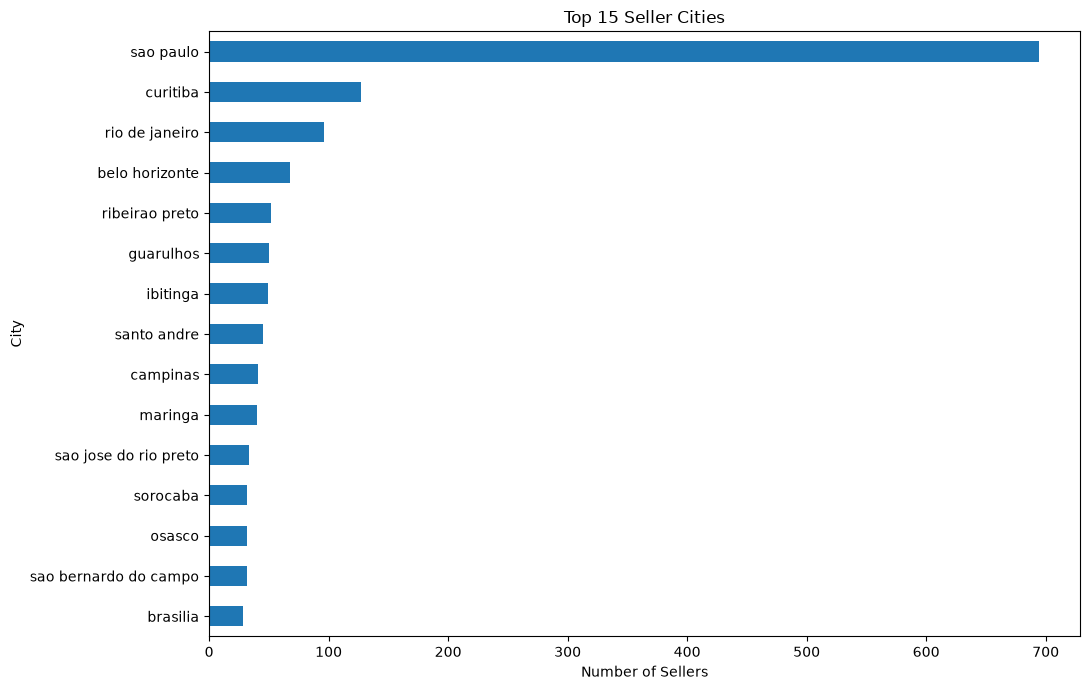

In [83]:
plt.figure(figsize=(11, 7))

top_seller_cities.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Seller Cities")
plt.xlabel("Number of Sellers")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    "../reports/figures/sellers/top_seller_cities.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 15. Geographic Analysis

This section compares customer demand and seller supply across Brazilian states.

The analysis can reveal geographic concentration and regions where customer demand may be less supported by local sellers.

### 15.1 Customer versus seller state counts

In [84]:
customer_state_counts = (
    customers.groupby("customer_state")
    .size()
    .rename("customers")
)

seller_state_counts = (
    sellers.groupby("seller_state")
    .size()
    .rename("sellers")
)

state_comparison = pd.concat(
    [
        customer_state_counts,
        seller_state_counts
    ],
    axis=1
).fillna(0)

state_comparison = (
    state_comparison
    .sort_values("customers", ascending=False)
)

state_comparison.head(10)

,customers,sellers
SP,41746,1849.0
RJ,12852,171.0
MG,11635,244.0
RS,5466,129.0
PR,5045,349.0
SC,3637,190.0
BA,3380,19.0
DF,2140,30.0
ES,2033,23.0
GO,2020,40.0


In [85]:
state_comparison["customer_share_pct"] = (
    state_comparison["customers"]
    / state_comparison["customers"].sum()
    * 100
)

state_comparison["seller_share_pct"] = (
    state_comparison["sellers"]
    / state_comparison["sellers"].sum()
    * 100
)

state_comparison.head(10)

,customers,sellers,customer_share_pct,seller_share_pct
SP,41746,1849.0,41.980672,59.741519
RJ,12852,171.0,12.924247,5.525040
MG,11635,244.0,11.700405,7.883683
RS,5466,129.0,5.496727,4.168013
PR,5045,349.0,5.073360,11.276252
SC,3637,190.0,3.657445,6.138934
BA,3380,19.0,3.399000,0.613893
DF,2140,30.0,2.152030,0.969305
ES,2033,23.0,2.044428,0.743134
GO,2020,40.0,2.031355,1.292407


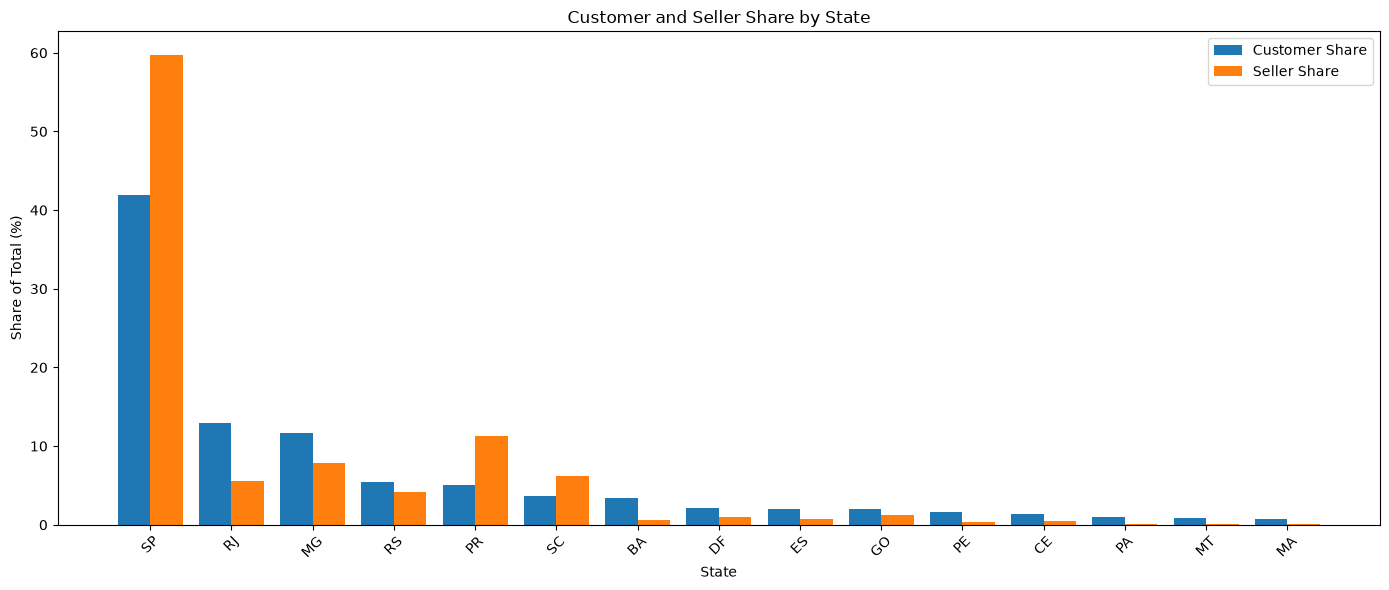

In [86]:
top_states = state_comparison.head(15)

x = np.arange(len(top_states))
width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - width / 2,
    top_states["customer_share_pct"],
    width,
    label="Customer Share"
)

plt.bar(
    x + width / 2,
    top_states["seller_share_pct"],
    width,
    label="Seller Share"
)

plt.title("Customer and Seller Share by State")
plt.xlabel("State")
plt.ylabel("Share of Total (%)")
plt.xticks(
    x,
    top_states.index,
    rotation=45
)
plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/geography/customer_seller_state_share.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 16.  Cross-Table Business Analysis

This section performs controlled joins to examine relationships between:

- Delivery performance and review scores
- Product prices and freight values
- Payment installments and payment values

Care is taken to preserve the correct grain of each table and avoid duplicate multiplication.

### 16.1 Delivery performance and review scores

In [87]:
reviews_by_order = (
    reviews.groupby("order_id", as_index=False)
    .agg(
        review_score=("review_score", "mean")
    )
)

In [88]:
delivery_reviews = (
    delivered_orders[
        [
            "order_id",
            "delivery_days",
            "delivery_difference_days",
            "late_delivery"
        ]
    ]
    .merge(
        reviews_by_order,
        on="order_id",
        how="inner"
    )
)

delivery_reviews.head()

,order_id,delivery_days,delivery_difference_days,late_delivery,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,-7.107488,False,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,-5.355729,False,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,-17.245498,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,-12.980069,False,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,-9.238171,False,5.0


In [89]:
review_by_delivery_status = (
    delivery_reviews.groupby("late_delivery")
    ["review_score"]
    .agg(["count", "mean", "median"])
)

review_by_delivery_status

,count,mean,median
late_delivery,,,
False,88163,4.294292,5.0
True,7661,2.566506,2.0


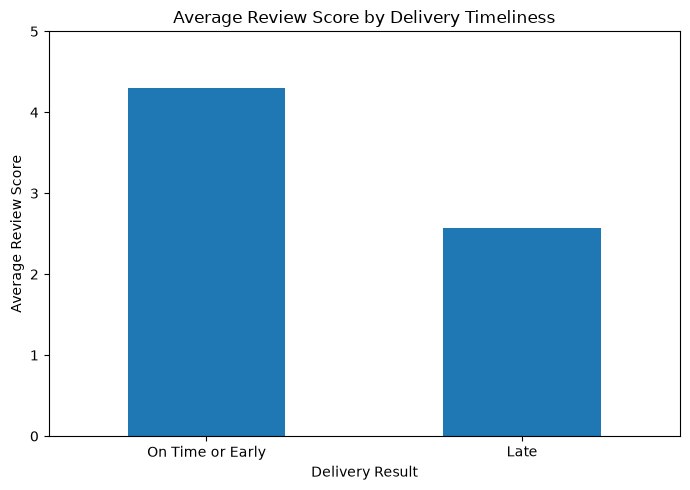

In [90]:
plot_data = (
    delivery_reviews.groupby("late_delivery")
    ["review_score"]
    .mean()
    .rename(index={
        False: "On Time or Early",
        True: "Late"
    })
)

plt.figure(figsize=(7, 5))

plot_data.plot(kind="bar")

plt.title("Average Review Score by Delivery Timeliness")
plt.xlabel("Delivery Result")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlations/review_score_by_delivery_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 16.2 Delivery delay versus review score

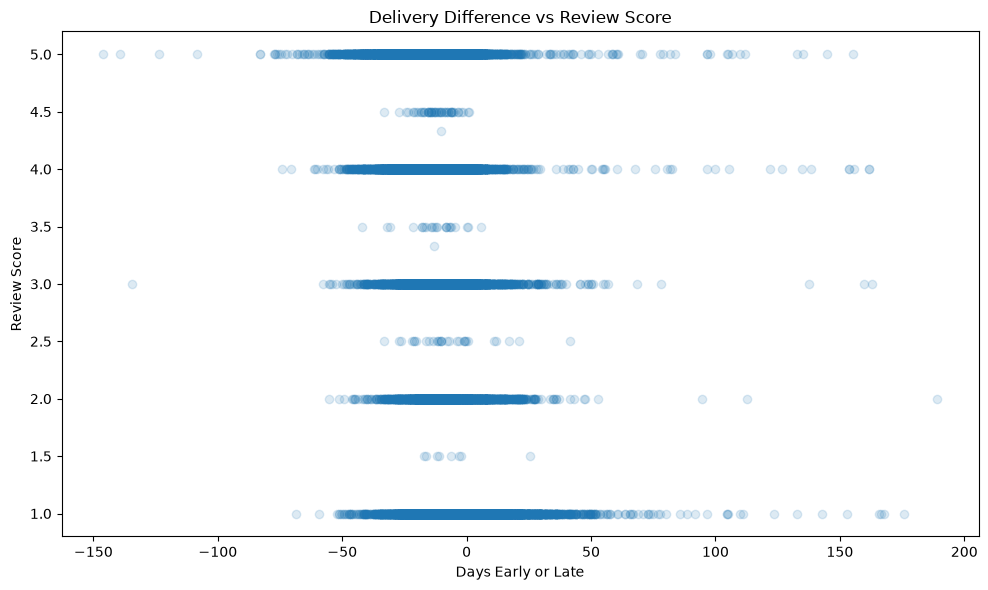

In [91]:
plt.figure(figsize=(10, 6))

plt.scatter(
    delivery_reviews["delivery_difference_days"],
    delivery_reviews["review_score"],
    alpha=0.15
)

plt.title("Delivery Difference vs Review Score")
plt.xlabel("Days Early or Late")
plt.ylabel("Review Score")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlations/delivery_difference_vs_review_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [92]:
delivery_review_correlation = (
    delivery_reviews[
        [
            "delivery_difference_days",
            "review_score"
        ]
    ]
    .corr()
)

delivery_review_correlation

,delivery_difference_days,review_score
delivery_difference_days,1.000000,-0.266908
review_score,-0.266908,1.000000


### 16.3 Price versus freight value

In [93]:
price_freight_sample = (
    order_items[
        ["price", "freight_value"]
    ]
    .dropna()
    .sample(
        n=min(10000, len(order_items)),
        random_state=42
    )
)

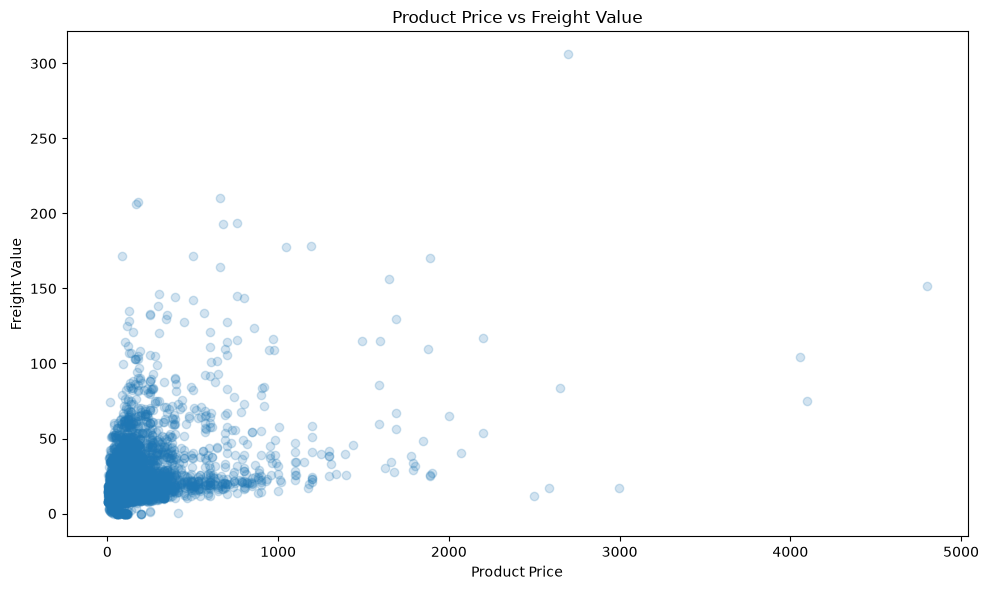

In [94]:
plt.figure(figsize=(10, 6))

plt.scatter(
    price_freight_sample["price"],
    price_freight_sample["freight_value"],
    alpha=0.2
)

plt.title("Product Price vs Freight Value")
plt.xlabel("Product Price")
plt.ylabel("Freight Value")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlations/price_vs_freight_value.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
order_items[
    ["price", "freight_value"]
].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


### 16.4 Installments versus payment value

In [96]:
installment_payment_summary = (
    payments.groupby("payment_installments")
    ["payment_value"]
    .agg(
        payment_records="count",
        average_payment="mean",
        median_payment="median"
    )
    .reset_index()
)

installment_payment_summary.head(20)

,payment_installments,payment_records,average_payment,median_payment
0,0,2,94.315000,94.315
1,1,52546,112.420229,73.340
2,2,12413,127.228150,109.420
3,3,10461,142.539317,110.420
4,4,7098,163.976840,117.175
5,5,5239,183.465222,125.970
6,6,3920,209.849952,138.550
7,7,1626,187.673672,140.075
8,8,4268,307.737427,212.695
9,9,644,203.440870,99.920


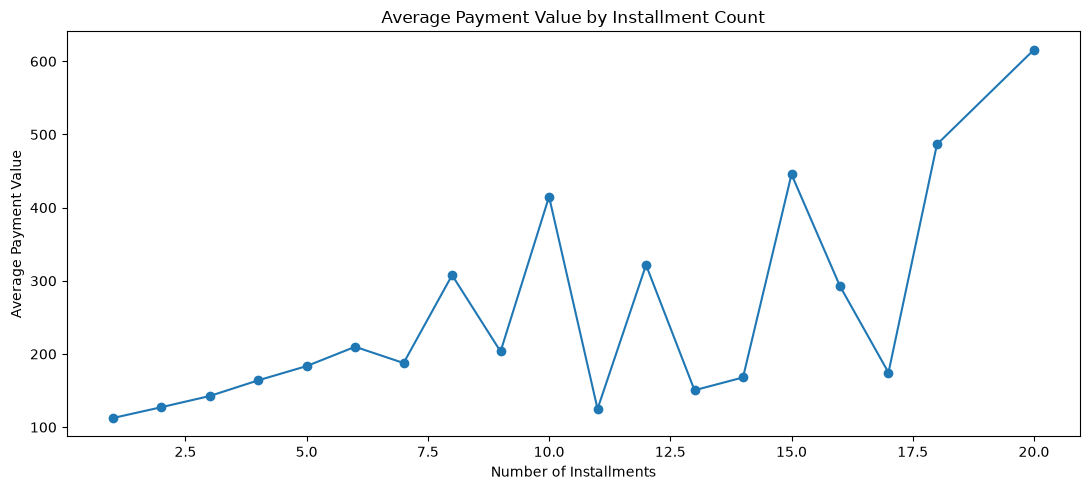

In [97]:
installment_plot = (
    installment_payment_summary[
        installment_payment_summary[
            "payment_installments"
        ].between(1, 20)
    ]
)

plt.figure(figsize=(11, 5))

plt.plot(
    installment_plot["payment_installments"],
    installment_plot["average_payment"],
    marker="o"
)

plt.title("Average Payment Value by Installment Count")
plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")

plt.tight_layout()

plt.savefig(
    "../reports/figures/correlations/payment_value_by_installments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 17. Preliminary Revenue Exploration

Product revenue is calculated from `order_items.price`.

Only delivered orders are used for preliminary completed-sales analysis.

Freight is kept separate from product revenue because it represents shipping charges rather than product sales.

### 17.1 Create delivered order-item data

In [98]:
delivered_order_ids = (
    orders.loc[
        orders["order_status"] == "delivered",
        [
            "order_id",
            "order_purchase_timestamp"
        ]
    ]
)

delivered_items = order_items.merge(
    delivered_order_ids,
    on="order_id",
    how="inner"
)

delivered_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,order_purchase_timestamp
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-13 08:59:02
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-04-26 10:53:06
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-14 14:33:31
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-08 10:00:35
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-04 13:57:51


### 17.2 Preliminary product revenue

In [99]:
preliminary_revenue = (
    delivered_items["price"].sum()
)

preliminary_freight = (
    delivered_items["freight_value"].sum()
)

print(
    "Preliminary delivered product revenue:",
    round(preliminary_revenue, 2)
)

print(
    "Delivered freight value:",
    round(preliminary_freight, 2)
)

Preliminary delivered product revenue: 13221498.11
Delivered freight value: 2198275.64


### 17.3 Monthly product revenue

In [100]:
delivered_items["purchase_year_month"] = (
    delivered_items[
        "order_purchase_timestamp"
    ].dt.to_period("M")
)

monthly_revenue = (
    delivered_items.groupby(
        "purchase_year_month"
    )["price"]
    .sum()
    .reset_index(name="product_revenue")
)

monthly_revenue[
    "purchase_year_month"
] = monthly_revenue[
    "purchase_year_month"
].astype(str)

monthly_revenue

,purchase_year_month,product_revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40
5,2017-03,359198.85
6,2017-04,340669.68
7,2017-05,489338.25
8,2017-06,421923.37
9,2017-07,481604.52


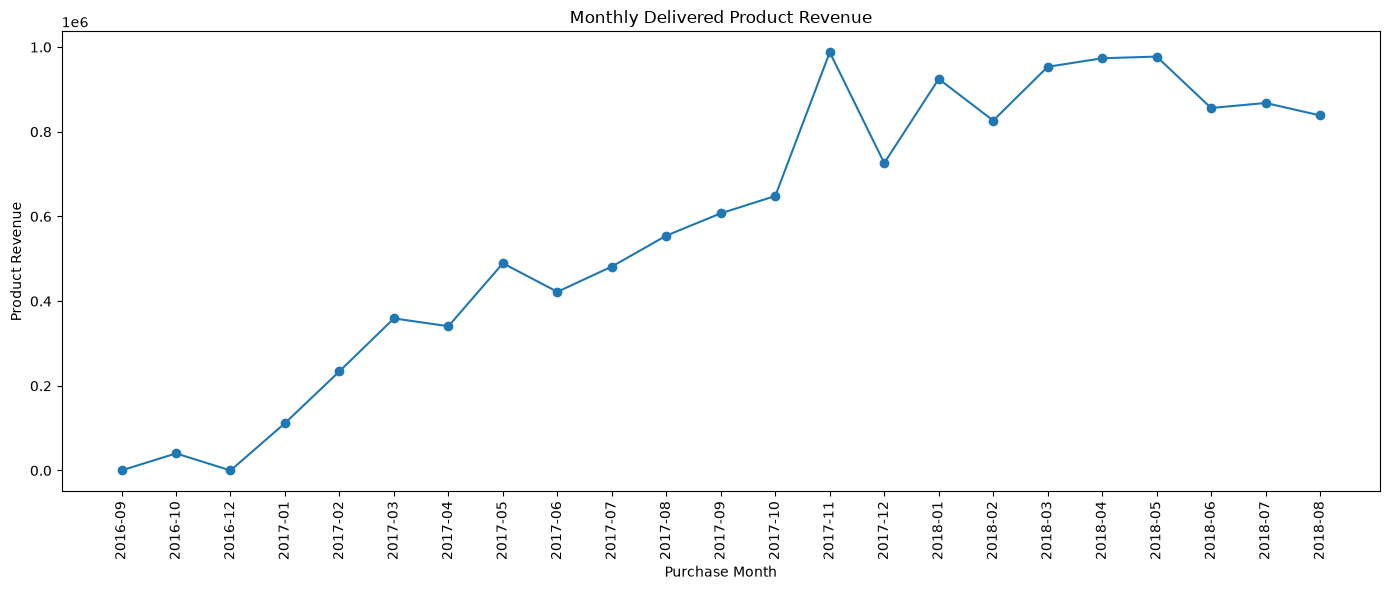

In [101]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["purchase_year_month"],
    monthly_revenue["product_revenue"],
    marker="o"
)

plt.title("Monthly Delivered Product Revenue")
plt.xlabel("Purchase Month")
plt.ylabel("Product Revenue")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "../reports/figures/orders/monthly_product_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 17.4 Average order value

In [102]:
delivered_order_totals = (
    delivered_items.groupby("order_id")
    .agg(
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        item_count=("order_item_id", "count")
    )
    .reset_index()
)

delivered_order_totals.head()

,order_id,product_revenue,freight_value,item_count
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


In [103]:
average_order_value = (
    delivered_order_totals[
        "product_revenue"
    ].mean()
)

print(
    "Preliminary average order value:",
    round(average_order_value, 2)
)

Preliminary average order value: 137.04


### 17.5 Revenue by product category

In [104]:
category_revenue = (
    delivered_items
    .merge(
        products_analysis[
            [
                "product_id",
                "product_category_name_english"
            ]
        ],
        on="product_id",
        how="left"
    )
)

category_revenue[
    "product_category_name_english"
] = category_revenue[
    "product_category_name_english"
].fillna("Unknown")

In [105]:
top_category_revenue = (
    category_revenue.groupby(
        "product_category_name_english"
    )["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_category_revenue

product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
garden_tools              470495.28
baby                      400421.84
perfumery                 390144.65
telephony                 309860.23
office_furniture          268154.31
Name: price, dtype: float64

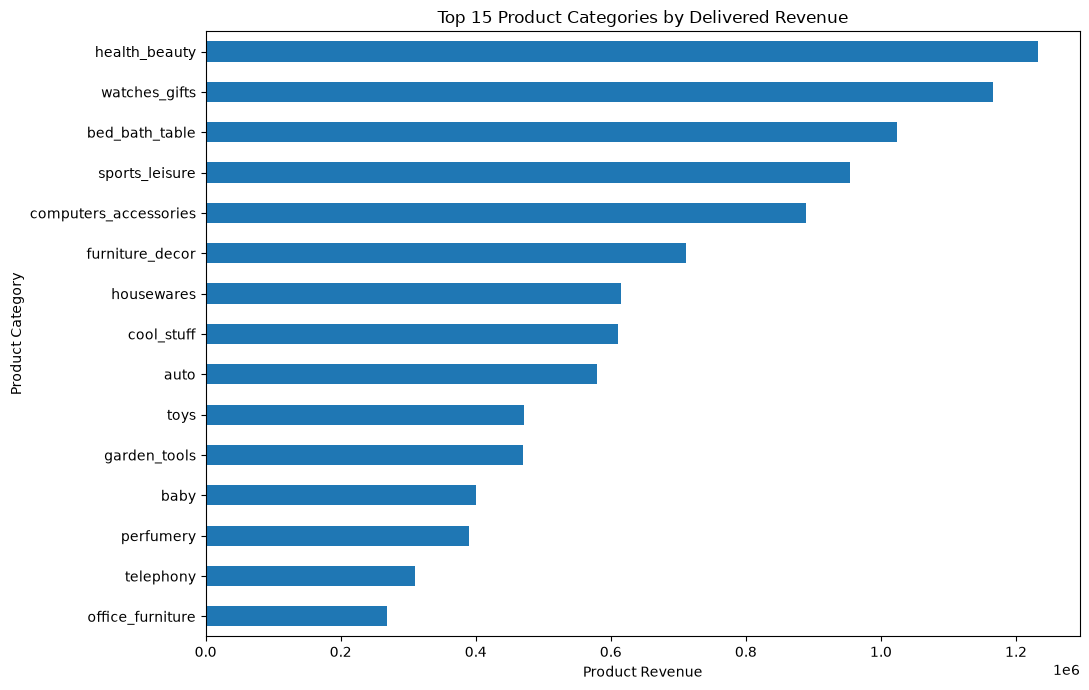

In [106]:
plt.figure(figsize=(11, 7))

top_category_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Product Categories by Delivered Revenue")
plt.xlabel("Product Revenue")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig(
    "../reports/figures/products/top_categories_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 18. Exploratory Data Analysis Findings

## Orders

- The dataset contains **99,441 order records**, and the overwhelming majority were successfully delivered.
- Delivered orders account for approximately **97% of all orders**, indicating a high overall completion rate.
- Cancelled, unavailable, shipped, processing, invoiced, created, and approved orders represent only a small proportion of the dataset.
- Order volume increased substantially from 2016 through 2018. However, the yearly comparison must be interpreted carefully because:
  - 2016 contains only a small number of initial records.
  - 2018 is incomplete and ends around September/October.
- The monthly trend shows strong growth throughout 2017, with a major peak in **November 2017**, likely associated with seasonal shopping activity such as Black Friday.
- Monthly order volume remained relatively high during the first eight months of 2018.
- The sharp decline after August 2018 does not represent a confirmed business decline; it is primarily caused by incomplete final reporting periods.
- Aggregated calendar-month totals appear highest around **May through August**, while September, October, and December appear lower. These totals are affected by the dataset's partial years and should not be treated as definitive seasonality.
- Order activity is highest on **Monday and Tuesday** and gradually declines toward the weekend.
- Saturday has the lowest order volume, while Sunday shows a slight recovery.
- Orders are least frequent between approximately **2:00 AM and 6:00 AM**.
- Purchase activity rises rapidly after 7:00 AM and remains consistently high from approximately **10:00 AM through 10:00 PM**.
- The hourly pattern suggests that customers predominantly shop during daytime and evening hours.

## Order Processing and Delivery

- Most orders are approved very quickly, with a large concentration close to zero or only a few hours after purchase.
- Approval time has a long right tail, meaning a smaller number of orders take considerably longer to receive approval.
- A visible concentration near approximately 24 hours may indicate payment-processing cycles or delayed confirmation for certain payment methods.
- Delivery time is right-skewed.
- Most completed orders appear to arrive within approximately **5–15 days**, while a smaller number require more than 30 or 40 days.
- The majority of delivered orders arrive **on time or earlier than estimated**.
- Late deliveries represent a relatively small minority of completed orders.
- The difference between actual and estimated delivery dates is concentrated below zero, showing that many orders arrive several days earlier than promised.
- A substantial number of orders appear to arrive roughly **7–15 days before** the estimated delivery date.
- Positive delivery differences represent late orders, including a small number of severe delays.

## Customers

- The customer table contains **99,441 customer records** representing approximately **96,096 unique customers**.
- The difference between `customer_id` and `customer_unique_id` confirms that some customers placed more than one order.
- `customer_unique_id` should therefore be used for repeat-purchase, retention, RFM, and customer-lifetime-value analysis.
- Customer demand is highly geographically concentrated.
- São Paulo state represents approximately **42% of customer records**, making it the largest customer market.
- Rio de Janeiro and Minas Gerais are the next-largest customer markets.
- The five largest states represent a substantial majority of the customer base.
- São Paulo city is the largest individual customer city.
- This geographic concentration suggests that regional demand and delivery performance should be analyzed separately rather than assuming uniform marketplace behavior across Brazil.

## Products

- The product catalog contains approximately **32,951 unique products**.
- Product categories are recorded in Portuguese and require the translation table for English-language reporting.
- Product categories vary substantially in catalog size and revenue contribution.
- Product counts alone should not be interpreted as product performance because a large catalog category does not necessarily generate the highest sales.
- Product prices are strongly right-skewed:
  - Most products have relatively low or moderate prices.
  - A small number of items have very high prices.
- Freight values are also right-skewed and contain several large outliers.
- These extreme observations should be flagged and investigated during cleaning rather than automatically removed, because they may represent legitimate large, heavy, or high-value products.

## Payments

- Credit cards are the dominant payment method in the dataset.
- Vouchers, boleto payments, debit cards, and other payment types represent considerably smaller shares.
- Most orders use a single payment record, but some orders contain multiple payment records.
- Payment records must therefore be aggregated to one row per order before being joined with order-item data.
- Directly joining raw payments and raw order items could produce many-to-many row multiplication and inflate revenue totals.
- Average payment value generally increases as installment count rises from one to approximately ten installments.
- Higher installment counts show substantial fluctuations.
- For example, average payment values are particularly high around 10, 15, 18, and 20 installments.
- These high-installment averages should not be interpreted alone because uncommon installment counts may contain relatively few observations and may therefore be sensitive to expensive individual orders.
- Final installment analysis should include both:
  - Average or median payment value
  - Number of payment records at each installment count

## Reviews

- The average review score is approximately **4.1 out of 5**, suggesting generally positive customer satisfaction.
- Five-star ratings are the most common review outcome.
- Written review titles and messages contain substantial missingness because customers can submit a numerical rating without written feedback.
- Missing review text should therefore be treated as optional customer behavior rather than automatically classified as a data-quality error.
- Delivery performance shows a clear association with customer satisfaction:
  - Orders delivered on time or early have an average review score of approximately **4.3**.
  - Late orders have an average review score of approximately **2.6**.
- This difference suggests that delivery reliability is an important contributor to customer experience.
- The delivery-difference scatterplot also shows that low scores become more common as the number of late days increases.
- However, review score is discrete and influenced by factors beyond delivery, including product quality, seller service, damaged products, and customer expectations.
- The observed relationship is associative and does not by itself prove causation.

## Sellers and Marketplace Geography

- The marketplace contains **3,095 sellers** operating across multiple Brazilian states and cities.
- Seller supply is even more geographically concentrated than customer demand.
- São Paulo state represents approximately **60% of sellers**, compared with around 42% of customers.
- Paraná is the second-largest seller state and holds a noticeably larger seller share than customer share.
- São Paulo city dominates the seller-city distribution, with roughly 700 sellers.
- Curitiba and Rio de Janeiro follow but contain far fewer sellers than São Paulo.
- Rio de Janeiro, Minas Gerais, Bahia, Pernambuco, Pará, and several other states have a larger share of customers than sellers.
- This imbalance suggests that many orders in those states may depend on sellers located elsewhere, potentially affecting:
  - Freight costs
  - Delivery times
  - Late-delivery risk
  - Customer satisfaction
- A future logistics analysis should compare delivery outcomes for same-state and cross-state orders.

## Revenue

- Preliminary delivered product revenue increased considerably throughout 2017.
- Revenue reached a major peak in **November 2017**, consistent with the peak in order volume.
- Monthly delivered product revenue remained high throughout much of 2018, generally around the upper range visible in the dataset.
- Revenue and order-count trends follow similar patterns, suggesting that growth was driven substantially by higher transaction volume.
- Differences between the two curves should later be examined using average order value.
- The first and final months contain incomplete observations and should be excluded or clearly marked in formal trend comparisons.
- Product revenue is calculated from `order_items.price`.
- Freight value is reported separately because it represents shipping charges rather than product sales.
- Payment value should not automatically be treated as identical to product revenue because payments can include freight and can be split across multiple payment records.

## Relationships Between Variables

### Product Price and Freight Value

- Product price and freight value show a weak positive relationship.
- Most observations are concentrated among lower-priced products with relatively low freight values.
- Higher-priced products can have either low or high freight charges, showing that price alone does not determine shipping cost.
- Freight is likely influenced more directly by:
  - Product weight
  - Product dimensions
  - Seller location
  - Customer location
  - Shipping distance
- Several extreme price and freight observations are visible and should be investigated during cleaning.

### Installments and Payment Value

- Customers using larger installment counts often have higher average payment values.
- This suggests that installments may help customers finance larger purchases.
- The relationship is not consistently linear, particularly above ten installments.
- Sparse observations and expensive outliers may strongly influence high-installment averages.
- Median values and record counts should be used alongside means before making final business recommendations.

### Delivery Performance and Reviews

- Delivery timeliness has the strongest visible business relationship identified during this EDA.
- On-time or early deliveries receive much higher average review scores than late deliveries.
- Reducing delayed deliveries could therefore potentially improve customer satisfaction and marketplace trust.
- Additional analysis should control for seller, category, freight value, state, and delivery distance before drawing stronger conclusions.

## Preliminary Business Interpretation

- The marketplace successfully completes most orders, but delivery delays have a meaningful negative relationship with customer satisfaction.
- Customer demand and seller supply are both highly concentrated in São Paulo, although seller concentration is substantially greater.
- States with high customer demand but low seller representation may face longer shipping distances and greater logistics risk.
- Business activity grew strongly during the observed period, with an especially important seasonal peak in November 2017.
- Customers generally purchase during daytime and evening hours and place more orders during weekdays than weekends.
- Credit cards and installment payments are central to purchasing behavior.
- Revenue appears concentrated in particular months, geographic markets, and product categories.
- These patterns create opportunities for:
  - Regional logistics optimization
  - Seller recruitment in underserved states
  - Delivery-risk monitoring
  - Seasonal inventory planning
  - Payment and installment strategy
  - Customer segmentation and targeted retention campaigns

## Important Limitations

- The first and final months are incomplete and can distort annual, monthly, and seasonal comparisons.
- The original dataset does not contain marketing-campaign costs, impressions, website-session events, or experiment assignments.
- Revenue calculations in this phase are preliminary and will be formally validated after data cleaning.
- Review text is optional and cannot be treated as a complete representation of customer feedback.
- Correlation and visual association do not prove causation.
- High installment counts may have small sample sizes.
- Several financial and operational variables contain extreme values that require investigation.
- Product revenue, customer payment value, and freight value represent different business concepts and should remain separately defined.

### 19. Save EDA Output Tables

In [108]:
from pathlib import Path

eda_output = Path("../data/generated/eda")

eda_output.mkdir(
    parents=True,
    exist_ok=True
)

In [109]:
status_summary.to_csv(
    eda_output / "order_status_summary.csv",
    index=True
)

In [110]:
monthly_orders.to_csv(
    eda_output / "monthly_orders.csv",
    index=False
)

In [111]:
if "monthly_revenue" not in globals():
    delivered_order_ids = orders.loc[
        orders["order_status"] == "delivered",
        ["order_id", "order_purchase_timestamp"]
    ].copy()
    delivered_order_ids["order_purchase_timestamp"] = pd.to_datetime(
        delivered_order_ids["order_purchase_timestamp"]
    )

    delivered_items = order_items.merge(
        delivered_order_ids,
        on="order_id",
        how="inner"
    )

    delivered_items["purchase_year_month"] = (
        delivered_items["order_purchase_timestamp"]
        .dt.to_period("M")
        .astype(str)
    )

    monthly_revenue = (
        delivered_items.groupby("purchase_year_month", as_index=False)["price"]
        .sum()
        .rename(columns={"price": "product_revenue"})
    )

monthly_revenue.to_csv(
    eda_output / "monthly_revenue.csv",
    index=False
)

In [112]:
if "state_comparison" not in globals():
    customer_state_counts = (
        customers.groupby("customer_state")
        .size()
        .rename("customers")
    )

    seller_state_counts = (
        sellers.groupby("seller_state")
        .size()
        .rename("sellers")
    )

    state_comparison = pd.concat(
        [customer_state_counts, seller_state_counts],
        axis=1
    ).fillna(0)

    state_comparison = state_comparison.sort_values(
        "customers",
        ascending=False
    )

state_comparison.to_csv(
    eda_output / "state_comparison.csv"
)

In [113]:
if "review_by_delivery_status" not in globals():
    if "delivery_reviews" not in globals():
        if "review_by_delivery_status" not in globals():
            if "delivery_reviews" not in globals():
                delivery_reviews = (
                    delivered_orders[
                        [
                            "order_id",
                            "delivery_difference_days",
                            "late_delivery"
                        ]
                    ]
                    .merge(
                        reviews_by_order,
                        on="order_id",
                        how="inner"
                    )
                )

            review_by_delivery_status = (
                delivery_reviews.groupby("late_delivery")["review_score"]
                .agg(["count", "mean", "median"])
            )

        review_by_delivery_status.to_csv(
            eda_output / "review_by_delivery_status.csv"
        )

    review_by_delivery_status = (
        delivery_reviews.groupby("late_delivery")["review_score"]
        .agg(["count", "mean", "median"])
    )

review_by_delivery_status.to_csv(
    eda_output / "review_by_delivery_status.csv"
)

In [114]:
if "installment_payment_summary" not in globals():
    installment_payment_summary = (
        payments.groupby("payment_installments")["payment_value"]
        .agg(
            payment_records="count",
            average_payment="mean",
            median_payment="median"
        )
        .reset_index()
    )

installment_payment_summary.to_csv(
    eda_output / "installment_payment_summary.csv",
    index=False
)

In [115]:
if "top_category_revenue" not in globals():
    category_revenue = (
        delivered_items
        .merge(
            products[["product_id", "product_category_name"]],
            on="product_id",
            how="left"
        )
        .merge(
            translation,
            on="product_category_name",
            how="left"
        )
    )

    category_revenue["product_category_name_english"] = (
        category_revenue["product_category_name_english"]
        .fillna("Unknown")
    )

    top_category_revenue = (
        category_revenue.groupby("product_category_name_english")["price"]
        .sum()
        .sort_values(ascending=False)
        .head(15)
    )

top_category_revenue.to_csv(
    eda_output / "category_revenue.csv"
)

In [116]:
print("EDA Output Files\n")

for file in sorted(eda_output.glob("*.csv")):
    print(file.name)

EDA Output Files

category_revenue.csv
delivered_order_totals.csv
installment_payment_summary.csv
monthly_orders.csv
monthly_revenue.csv
order_status_summary.csv
review_by_delivery_status.csv
state_comparison.csv
yearly_orders.csv


In [117]:
from pathlib import Path

report_dir = Path("../reports/documentation")

report_dir.mkdir(
    parents=True,
    exist_ok=True
)

report_path = report_dir / "eda_summary.md"

In [118]:
with open(report_path, "w", encoding="utf-8") as f:

    f.write("# Exploratory Data Analysis Summary\n\n")

    f.write(
        "This report summarizes the major findings from the exploratory analysis of the Olist E-commerce dataset.\n\n"
    )

    f.write("## Dataset Overview\n\n")
    f.write("- Orders: 99,441\n")
    f.write("- Unique Customers: 96,096\n")
    f.write("- Sellers: 3,095\n")
    f.write("- Products: 32,951\n\n")

    f.write("## Key Findings\n\n")

    findings = [
        "Approximately 97% of orders were successfully delivered.",
        "Order volume and revenue increased steadily through 2017.",
        "November 2017 recorded the highest sales activity.",
        "Customers primarily purchased during weekdays and daytime hours.",
        "São Paulo represented the largest customer and seller market.",
        "Credit cards were the dominant payment method.",
        "Most deliveries occurred within 5–15 days.",
        "Late deliveries were associated with significantly lower review scores.",
        "Product prices and freight values were heavily right-skewed.",
        "Several product and freight outliers appear to be legitimate business observations.",
        "Delivery reliability appears to be one of the strongest drivers of customer satisfaction."
    ]

    for item in findings:
        f.write(f"- {item}\n")

    f.write("\n")

    f.write("## Generated Tables\n\n")

    tables = [
        "order_status_summary.csv",
        "monthly_orders.csv",
        "monthly_revenue.csv",
        "state_comparison.csv",
        "review_by_delivery_status.csv",
        "installment_payment_summary.csv",
        "category_revenue.csv"
    ]

    for table in tables:
        f.write(f"- {table}\n")

    f.write("\n")

    f.write("## Generated Figures\n\n")

    f.write(
        "Charts for orders, customers, products, payments, reviews, logistics, sellers, geography, and correlations are available under reports/figures/.\n\n"
    )

    f.write("## Next Phase\n\n")

    f.write(
        "The next phase performs data cleaning, feature engineering, and validation before loading the cleaned datasets into PostgreSQL.\n"
    )

print("EDA summary report generated successfully.")

EDA summary report generated successfully.


# Phase 3 Completed

The exploratory data analysis phase is complete.

Deliverables produced:

- Exploratory analysis notebook
- Business insights
- Saved visualizations
- EDA output tables
- EDA summary report

The project is now ready for **Phase 4 – Data Cleaning and Feature Engineering**, where the datasets will be cleaned, validated, and transformed for PostgreSQL, SQL analytics, and Tableau dashboards.